# Building a training dataset for drug repositioning in Parkinson disease: a proof-of-concept of the CompDReAM approach

##### Written by: Florion Peni, UCL
##### Supervisor: Prof Edith Chan, UCL
-----
### UMLS API access and license requirements

Running this notebook requires obtaining a **license** and **API key** from the **National Library of Medicine (NLM)** for the **Unified Medical Language System (UMLS) API**. The UMLS REST API requires authentication through a UMLS account. If you do not have an account, you can apply for a license via the [UMLS Terminology Services (UTS) website](https://uts.nlm.nih.gov/).

The UMLS integrates and distributes key terminologies, classification systems, and coding standards, providing essential resources for the development of interoperable biomedical information systems, including electronic health records.

### CUIs and MeSH UID Mapping

In the UMLS, each **Concept Unique Identifier (CUI)** represents a distinct biomedical concept, linking terms and synonyms from various medical vocabularies, such as **MeSH**, **SNOMED CT**, and **ICD**, under a single identifier. This standardisation enhances interoperability across different databases and facilitates the integration of biomedical knowledge.

However, *UMLS may associate a single MeSH Unique Identifier (MeSH UID) with multiple CUIs*. To ensure accurate mapping, **MedGen** reports all valid mappings from UMLS.

To perform **CID-to-MeSH UID mapping**, we utilised the `MedGenIDMappings.txt` file (2025 version), downloaded from the [MedGen FTP site](https://ftp.ncbi.nlm.nih.gov/pub/medgen/). A precomputed CUI-to-MeSH UID mapping file ([`CUI_to_MeSH.csv`](CUI_to_MeSH.csv)) has been made available in the `data` folder and the code for generating it has been commented out in the first cell.

The `fetch_mesh_from_cui(cui)` function first checks [`CUI_to_MeSH.csv`](CUI_to_MeSH.csv). If the CUI exists in the mapping dictionary (`cui_mesh_mapping`), it returns the stored MeSH UID.  If no mapping is found in the file, the code queries the UMLS REST API. It then parses the API response to find a MeSH UID from the `"sourceDescriptor"` field under the `"MSH"` root source. If a valid mapping is found, it updates the dictionary to avoid redundant API requests in the future.

The `fetch_mesh_name(mesh_id)` function ensures that the MeSH UIDs obtained from CUIs are **correctly mapped to their standardised disease names**, allowing for clearer data interpretation and analysis. It directly queries the UMLS REST API by dynamically constructing request URLs.

As a proof of concept, we begin by loading the `DISEASES_Summary_GDA_CURATED_C0030567.tsv` file obtained from **[DisGeNET](!https://disgenet.com)** by querying the term *"Parkinson Disease"* (CUI: C0030567). To analyse a different disease, the variables `file_path`, `API_KEY`, and `CUI` must be updated accordingly before running the programme.

Note that the results shown here were obtained using a DisGeNET **academic license**.<sup>[1]</sup>

<sup>[1]: Academic users have access only to curated data sources, which include: PSYGENET, ORPHANET, CLINGEN, CLINVAR, UNIPROT, and RGD_HUMAN.</sup>

In [1]:
import sys
sys.path.append("../src")

import utils.skip_magic

import requests
import time
import glob
import os
import re
import cache
import json
import gzip
import shutil
import chembl_downloader
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import ast
import pandas as pd
import seaborn as sns
import numpy as np
import umap.umap_ as umap
from matplotlib.lines import Line2D
from matplotlib_venn import venn3
from adjustText import adjust_text
from upsetplot import from_memberships, UpSet
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from collections import defaultdict
from io import StringIO
from chembl_webresource_client.new_client import new_client
from scipy.stats import spearmanr
from math import pi
from urllib.request import urlopen

#medgen_df = pd.read_csv("../data/MedGenIDMappings.txt", sep="|", dtype=str, skiprows=1,
#names=["CUI", "pref_name", "source_id", "source", "unknown"])
#medgen_df = medgen_df.map(lambda x: x.strip() if isinstance(x, str) else x)
#cui_mesh_df = medgen_df[medgen_df["source"].str.strip() == "MeSH"][["CUI", "source_id"]]
#cui_mesh_df = cui_mesh_df.rename(columns={"source_id": "MSH"})
#cui_mesh_df = cui_mesh_df.dropna(subset=["MSH"])
#cui_mesh_df.to_csv("data/CUI_to_MeSH.csv", index=False)

file_path = "../data/DISEASES_Summary_GDA_CURATED_C0030567.tsv"  # Change for your desired file
API_KEY = "7eaf32db-24f3-4d66-b3cc-cc9a1ad56f9a"  # Replace with your actual UMLS API key
API_DELAY = 0.8
CUI = "C0030567"  # Change with CUI corresponding to your .tsv file from DisGeNET
BASE_URL = "https://uts-ws.nlm.nih.gov/rest/content/current/"
cui_mesh_mapping = pd.read_csv("../data/CUI_to_MeSH.csv", dtype=str).set_index("CUI")["MSH"].to_dict()

def fetch_mesh_from_cui(cui):
    """Fetches the MeSH ID from the precomputed mapping file or UMLS API."""
    # Checks if CUI exists in precomputed mappings
    if cui in cui_mesh_mapping:
        return cui_mesh_mapping[cui]
    # If not found, queries UMLS API
    cui_url = f"{BASE_URL}CUI/{cui}/atoms?apiKey={API_KEY}"
    response = requests.get(cui_url)
    if response.status_code == 200:
        data = response.json()
        for result in data.get("result", []):
            if result["rootSource"].startswith("MSH") and "sourceDescriptor" in result:
                mesh_id = result["sourceDescriptor"].split("/")[-1]
                # Updates the dictionary with the new mapping to avoid repeated API calls
                cui_mesh_mapping[cui] = mesh_id
                return mesh_id
    print(f"MeSH ID not found for CUI: {cui}")
    return None

def fetch_mesh_name(mesh_id, name_dict=None):
    """Fetches the normalised MeSH disease name from the UMLS API."""
    # Exclude only known non-MeSH formats, but keep valid 'C' prefix MeSH IDs
    if not mesh_id or mesh_id.startswith("U") or mesh_id.startswith("V-MSH"):
        return None
    # Use name_dict if provided, otherwise skip dictionary check
    if name_dict and mesh_id in name_dict:
        return name_dict[mesh_id]
    try:
        time.sleep(API_DELAY)
        url = f"{BASE_URL}source/MSH/{mesh_id}?apiKey={API_KEY}"
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if "result" in data and "name" in data["result"]:
                return data["result"]["name"]
    except Exception as e:
        print(f"Error fetching MeSH name for {mesh_id}: {e}")
    return None

selected_mesh_id = fetch_mesh_from_cui(CUI)
selected_mesh_name = fetch_mesh_name(selected_mesh_id)

if selected_mesh_id and selected_mesh_name:
    print(f"MeSH ID for {selected_mesh_name} is {selected_mesh_id}.")
else:
    print("Failed to fetch MeSH ID or name.")

/Users/florionpeni/anaconda3/envs/compdream/lib/python3.13/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


MeSH ID for Parkinson Disease is D010300.


After loading the dataset, the script removes unnecessary columns to retain only relevant gene-disease association data. It also corrects a known typo in the `"UnitProt"` column, renaming it to `"UniProt"`.

In [2]:
df = pd.read_csv(file_path, sep="\t")
columns_to_drop = [
    "DOClass", "Disease", "DiseaseClass", "FirstRef", "LastRef", "SemanticType", "Type",
    "EvidenceIndexGDA", "EvidenceLevelGDA", "GeneDPI", "GeneDSI", "GenePLI", "HPOClass",
    "geneEnsemblIDs", "numCTs", "NumVariantsDisease", "NumGenesDisease",
    "NumDiseasesAssociatedToGene", "NumPMIDs", "NumVariantsAssociatedToGene",
    "NumVariantsGDA", "diseaseUMLSCUI", "numberChemsIncludedInEvidence",
    "numberPmidsWithChemsIncludedInEvidence"
]
df_filtered = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors="ignore")
df_filtered.rename(columns={"UnitProt": "UniProt"}, inplace=True)
df_filtered

,Gene,GeneFullName,PathwayIDs,PathwayNames,ProteinClass,ScoreGDA,UniProt,geneNcbiID,geneNcbiType
0,SNCA,synuclein alpha,"R-HSA-168256,R-HSA-392499","Immune System,Metabolism of proteins",Transporter,1.00,"P37840,H6UYS5",6622,protein-coding
1,LRRK2,leucine rich repeat kinase 2,R-HSA-162582,Signal Transduction,Kinase,1.00,"Q17RV3,Q5S007",120892,protein-coding
2,GBA1,glucosylceramidase beta 1,"R-HSA-1430728,R-HSA-392499","Metabolism,Metabolism of proteins",NaN,1.00,"B7Z6S9,P04062,A0A068F658",2629,protein-coding
3,PRKN,parkin RBR E3 ubiquitin protein ligase,"R-HSA-168256,R-HSA-392499,R-HSA-5357801,R-HSA-...","Immune System,Metabolism of proteins,Programme...",Enzyme,1.00,"X5DR79,O60260",5071,protein-coding
4,VPS35,VPS35 retromer complex component,R-HSA-162582,Signal Transduction,Transporter,1.00,Q96QK1,55737,protein-coding
5,PINK1,PTEN induced kinase 1,"R-HSA-74160,R-HSA-9612973","Gene expression (Transcription),Autophagy",Kinase,1.00,Q9BXM7,65018,protein-coding
6,PARK7,Parkinsonism associated deglycase,"R-HSA-392499,R-HSA-9612973","Metabolism of proteins,Autophagy",Enzyme,1.00,"Q99497,V9HWC2",11315,protein-coding
7,GDNF,glial cell derived neurotrophic factor,"R-HSA-1266738,R-HSA-162582","Developmental Biology,Signal Transduction",Signaling,1.00,"P39905,A0A0S2Z3T2,A0A0S2Z3V2",2668,protein-coding
8,MAPT,microtubule associated protein tau,"R-HSA-112316,R-HSA-168256,R-HSA-5357801","Neuronal System,Immune System,Programmed Cell ...",NaN,1.00,"B3KTM0,P10636",4137,protein-coding
9,BDNF,brain derived neurotrophic factor,"R-HSA-162582,R-HSA-1643685,R-HSA-74160","Signal Transduction,Disease,Gene expression (T...",Signaling,1.00,"A0A0E3SU01,P23560",627,protein-coding


To enable our algorithm to access **drug data**, which is not available via DisGeNET's academic license, we incorporate the **ChEMBL 35 targets file**. This dataset contains information on **16,003 protein targets** and is available as a `.csv` file from the [ChEMBL Target Explorer](https://www.ebi.ac.uk/chembl/explore/targets/).

Genes associated with multiple UniProt IDs (e.g., `"P12345;Q67890"`) were split into individual entries using the `.explode()` method. After merging with ChEMBL target data, we regrouped the dataset to ensure that **all UniProt accession codes and associated ChEMBL target IDs** were retained. This approach ensures that genes linked to **multiple protein targets** retain **all relevant drug-target information** for downstream analysis.

In [3]:
# Load ChEMBL target data
chembl_target_path = "../data/ChEMBL35Targets.csv"
chembl_target_df = pd.read_csv(chembl_target_path, sep=";")

# Filter for human targets
human_targets = chembl_target_df[chembl_target_df["Organism"] == "Homo sapiens"].copy()

# Expand UniProt column (split multiple IDs) & map to ChEMBL target IDs
df_expanded = df_filtered.assign(UniProt=df_filtered["UniProt"].str.split(",")).explode("UniProt")
human_targets["UniProt Accessions"] = human_targets["UniProt Accessions"].astype(str).str.strip()
df_expanded["UniProt"] = df_expanded["UniProt"].astype(str).str.strip()
merged_df = df_expanded.merge(human_targets[['ChEMBL ID', 'UniProt Accessions']],
                              left_on="UniProt", right_on="UniProt Accessions",
                              how="left")

# Group by gene, keeping all ChEMBL and UniProt IDs
merged_df = merged_df.groupby("Gene").agg({
    "ChEMBL ID": lambda x: ",".join(x.dropna().unique()),
    "UniProt": lambda x: ",".join(x.dropna().unique()),
    **{col: lambda x: ",".join(x.dropna().astype(str).unique()) 
       for col in df_filtered.columns if col not in ["Gene", "UniProt"]}
}).reset_index()

# Remove rows with NaN values for ChEMBL target IDs
merged_df = merged_df[merged_df["ChEMBL ID"].notna() & (merged_df["ChEMBL ID"] != "")]

# Sort by highest ScoreGDA
if "ScoreGDA" in merged_df.columns:
    merged_df = merged_df.sort_values(by="ScoreGDA", ascending=False)

# Rename column and save final dataset
merged_df.rename(columns={"ChEMBL ID": "ChEMBLTargetID"}, inplace=True)
merged_df

,Gene,ChEMBLTargetID,UniProt,GeneFullName,PathwayIDs,PathwayNames,ProteinClass,ScoreGDA,geneNcbiID,geneNcbiType
29,VPS35,CHEMBL2216744,Q96QK1,VPS35 retromer complex component,R-HSA-162582,Signal Transduction,Transporter,1.0,55737,protein-coding
12,LRRK2,CHEMBL1075104,"Q17RV3,Q5S007",leucine rich repeat kinase 2,R-HSA-162582,Signal Transduction,Kinase,1.0,120892,protein-coding
18,PARK7,CHEMBL5169188,"Q99497,V9HWC2",Parkinsonism associated deglycase,"R-HSA-392499,R-HSA-9612973","Metabolism of proteins,Autophagy",Enzyme,1.0,11315,protein-coding
17,NR4A2,CHEMBL5002,"Q53EL4,P43354,F1D8N6",nuclear receptor subfamily 4 group A member 2,"R-HSA-392499,R-HSA-74160","Metabolism of proteins,Gene expression (Transc...",Nuclear receptor,1.0,4929,protein-coding
2,BDNF,CHEMBL4523205,"A0A0E3SU01,P23560",brain derived neurotrophic factor,"R-HSA-162582,R-HSA-1643685,R-HSA-74160","Signal Transduction,Disease,Gene expression (T...",Signaling,1.0,627,protein-coding
15,MAPT,CHEMBL1293224,"B3KTM0,P10636",microtubule associated protein tau,"R-HSA-112316,R-HSA-168256,R-HSA-5357801","Neuronal System,Immune System,Programmed Cell ...",,1.0,4137,protein-coding
13,MAOB,CHEMBL2039,"B7Z242,P27338",monoamine oxidase B,R-HSA-1430728,Metabolism,,1.0,4129,protein-coding
19,PINK1,CHEMBL3337330,Q9BXM7,PTEN induced kinase 1,"R-HSA-74160,R-HSA-9612973","Gene expression (Transcription),Autophagy",Kinase,1.0,65018,protein-coding
25,SNCA,CHEMBL6152,"P37840,H6UYS5",synuclein alpha,"R-HSA-168256,R-HSA-392499","Immune System,Metabolism of proteins",Transporter,1.0,6622,protein-coding
6,GBA1,CHEMBL2179,"B7Z6S9,P04062,A0A068F658",glucosylceramidase beta 1,"R-HSA-1430728,R-HSA-392499","Metabolism,Metabolism of proteins",,1.0,2629,protein-coding


---

### ChEMBL data quality & filtering criteria

We begin by retrieving all available `pChEMBL` values from ChEMBL, then simulate binary activity labels at two cut-offs:

* **5.0**, the widely used literature standard (equivalent to 10 µM), and
* **5.59**, the threshold that yields the most balanced class distribution (i.e. where the number of active and inactive compounds is nearly equal).

We first visualise the raw distribution of `pChEMBL` values, then compare how class assignments differ at both thresholds. The results show that the commonly used **5.0 threshold leads to a highly imbalanced dataset**, with the vast majority of compounds being classified as active. In contrast, **a data-driven threshold like 5.59 results in a more even and interpretable split**, which is especially beneficial for training binary classifiers.

This approach aligns with findings from Lenselink et al., who demonstrated that deep neural networks achieved significantly better performance on ChEMBL bioactivity benchmarks when trained using more stringent thresholds (e.g. **pChEMBL ≥ 6.5**) to define active compounds.<sup>[2]</sup>

<sup>[2]: E. B. Lenselink, N. ten Dijke, B. Bongers, G. Papadatos, H. W. T. van Vlijmen, W. Kowalczyk, A. P. IJzerman and G. J. P. van Westen, *J Cheminf*, 2017, DOI:[10.1186/s13321-017-0232-0](https://doi.org/10.1186/s13321-017-0232-0).</sup>

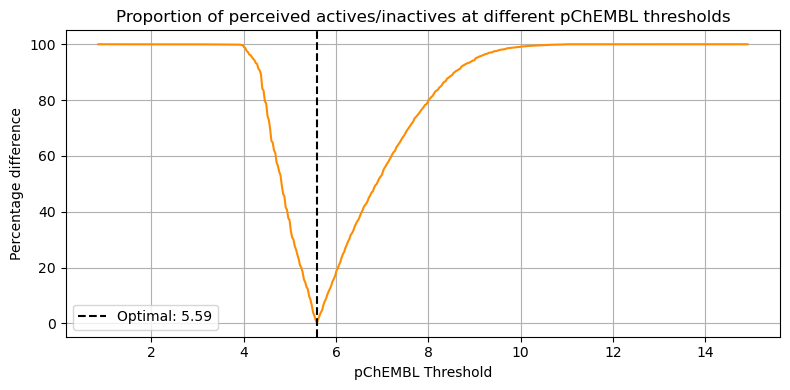

/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/2713223228.py:43: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_pchembl["active_5"], discrete=True, shrink=0.7, palette='Reds')
/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/2713223228.py:49: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df_pchembl["active_5_59"], discrete=True, shrink=0.7, palette='Blues')


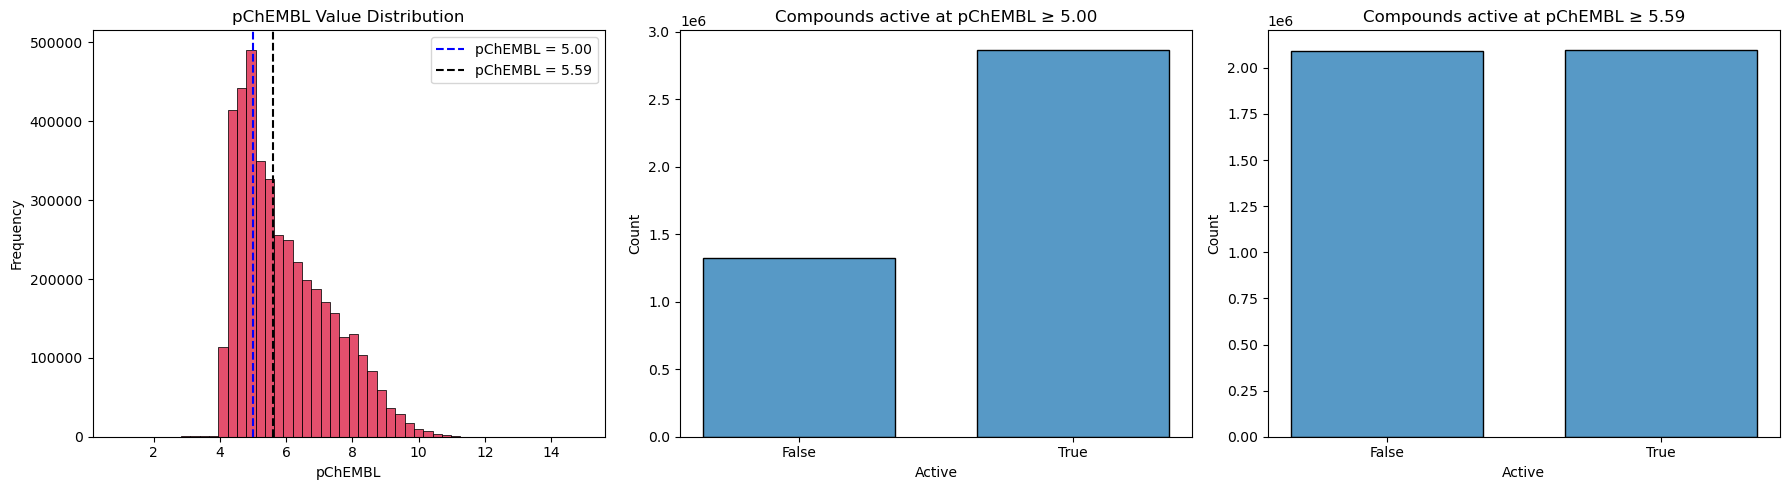

In [4]:
sql_pchembl = """
SELECT pchembl_value
FROM activities
WHERE pchembl_value IS NOT NULL
"""
df_pchembl = chembl_downloader.query(sql_pchembl)
df_pchembl["active_5"] = df_pchembl["pchembl_value"] >= 5.00
df_pchembl["active_5_59"] = df_pchembl["pchembl_value"] >= 5.59

# Identify the threshold where class balance is most equal
pchembl_vals = df_pchembl["pchembl_value"].dropna().sort_values().values
thresholds = np.linspace(pchembl_vals.min(), pchembl_vals.max(), 500)
total = len(pchembl_vals)
differences = [
    abs((pchembl_vals >= t).sum() - (pchembl_vals < t).sum()) / total * 100
    for t in thresholds
]
optimal_threshold = thresholds[np.argmin(differences)]

# Class imbalance vs. threshold
plt.figure(figsize=(8, 4))
plt.plot(thresholds, differences, color='darkorange')
plt.axvline(optimal_threshold, color='black', linestyle='--', label=f'Optimal: {optimal_threshold:.2f}')
plt.title("Proportion of perceived actives/inactives at different pChEMBL thresholds")
plt.xlabel("pChEMBL Threshold")
plt.ylabel("Percentage difference")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Histograms
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.histplot(df_pchembl["pchembl_value"], bins=50, color="crimson")
plt.axvline(5.00, color='blue', linestyle='--', label='pChEMBL = 5.00')
plt.axvline(5.59, color='black', linestyle='--', label='pChEMBL = 5.59')
plt.title("pChEMBL Value Distribution")
plt.xlabel("pChEMBL")
plt.ylabel("Frequency")
plt.legend()
plt.subplot(1, 3, 2)
sns.histplot(df_pchembl["active_5"], discrete=True, shrink=0.7, palette='Reds')
plt.xticks([0, 1], ['False', 'True'])  # Clean x-axis labels
plt.title("Compounds active at pChEMBL ≥ 5.00")
plt.xlabel("Active")
plt.ylabel("Count")
plt.subplot(1, 3, 3)
sns.histplot(df_pchembl["active_5_59"], discrete=True, shrink=0.7, palette='Blues')
plt.xticks([0, 1], ['False', 'True'])  # Clean x-axis labels
plt.title("Compounds active at pChEMBL ≥ 5.59")
plt.xlabel("Active")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

---

### Scoring the genes

#### Creating a normalised Modulator Score (MS)

This section queries the ChEMBL database to retrieve **the number of modulators per target where pChEMBL ≥ 5.59**, i.e. small molecules, proteins, peptides, oligonucleotides and oligosaccharides. The goal is to prioritise targets that have many potent binders. The hard-coded pChEMBL threshold of 5.59 could be adapted in future versions to reflect dynamical **target class-specific potency expectations**.

After collecting the modulator counts for all eligible ChEMBL targets, the **global maximum** is used as a fixed benchmark, so the gene with the most potent modulators receives an **MS = 1.0**, and all other genes are scaled accordingly. Thus, MS consistently reflects how modulated each eligible gene product is, relative to **all human ChEMBL targets**, not just those within the current study list. This makes the score both **biologically interpretable** and **comparable across studies**. Genes without modulators get an **MS = 0**.

The retrieved data is then merged with the existing dataset to associate **modulator counts** with genes.

> While MS incorporates multiple molecule types, many biologics (e.g. antibodies) lack pChEMBL values. Consequently, targets that are only druggable via these modalities may be overlooked, and additional steps are needed to ensure they are appropriately captured.

##### This code leverages the [`chembl_downloader`](https://github.com/cthoyt/chembl-downloader)  package, developed by @cthoyt. 

##### Refer to [`schema_documentation.html`](https://ftp.ebi.ac.uk/pub/databases/chembl/ChEMBLdb/latest/schema_documentation.html) for a more detailed explanation of the ChEMBL 35 schema.</sup>

/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/3574752613.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_molecules.groupby(["max_phase_labelled", "availability_group"]).size().unstack(fill_value=0)


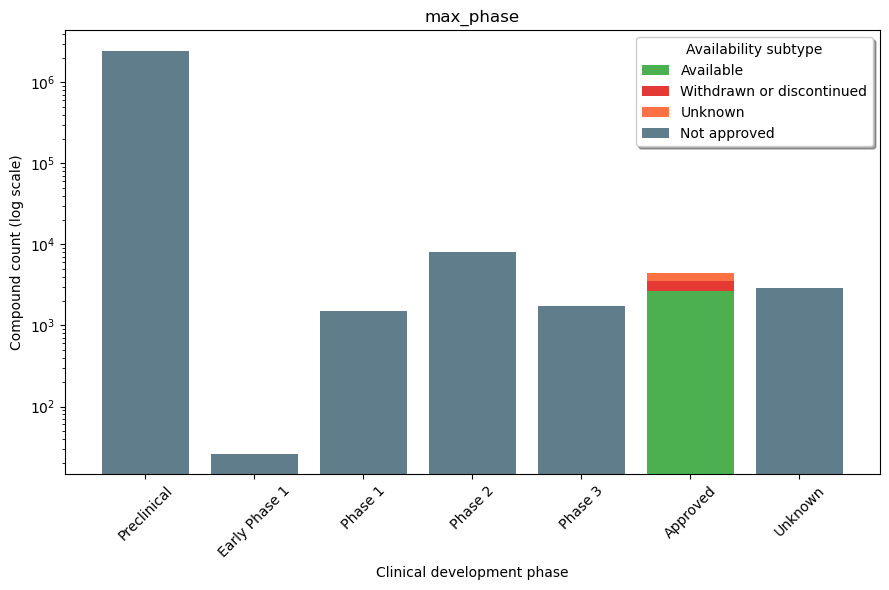

In [5]:
# This relates to scoring further down MS

sql_molecules = """
SELECT 
    max_phase,
    therapeutic_flag,
    molecule_type,
    first_in_class,
    availability_type,
    withdrawn_flag,
    chemical_probe,
    orphan
FROM molecule_dictionary
"""
df_molecules = chembl_downloader.query(sql_molecules)
df_molecules["max_phase_labelled"] = df_molecules["max_phase"].map({
    -1: "Unknown",
    0.5: "Early Phase 1",
    1: "Phase 1",
    2: "Phase 2",
    3: "Phase 3",
    4: "Approved"
})
df_molecules["max_phase_labelled"] = df_molecules["max_phase_labelled"].fillna("Preclinical")
ordered_phases = ["Preclinical", "Early Phase 1", "Phase 1", "Phase 2", "Phase 3", "Approved", "Unknown"]
df_molecules["max_phase_labelled"] = pd.Categorical(df_molecules["max_phase_labelled"], categories=ordered_phases, ordered=True)

def availability_group(row):
    if row["max_phase_labelled"] != "Approved":
        return "Not approved"
    if row["availability_type"] in [-2, 0]:
        return "Withdrawn or discontinued"
    elif row["availability_type"] in [1, 2]:
        return "Available"
    else:
        return "Unknown"

df_molecules["availability_group"] = df_molecules.apply(availability_group, axis=1)
grouped = df_molecules.groupby(["max_phase_labelled", "availability_group"]).size().unstack(fill_value=0)

# Collapse non-approved phases under "Not approved"
for phase in grouped.index:
    if phase != "Approved":
        total = grouped.loc[phase].sum()
        grouped.loc[phase] = 0
        grouped.loc[phase, "Not approved"] = total

# Column order using your exact labels
ordered_cols = [
    "Available",
    "Withdrawn or discontinued",
    "Unknown",
    "Not approved"
]
grouped = grouped[[col for col in ordered_cols if col in grouped.columns]]

# Colors using your labels
colors = {
    "Available": "#4CAF50",                         # Green
    "Withdrawn or discontinued": "#E53935",         # Red
    "Unknown": "#FF7043",                           # Orange
    "Not approved": "#607D8B"                       # Blue-grey
}
fig, ax = plt.subplots(figsize=(9, 6))
bottom = None
for category in grouped.columns:
    ax.bar(
        grouped.index,
        grouped[category],
        bottom=bottom,
        label=category,
        color=colors.get(category, "gray")
    )
    bottom = grouped[category] if bottom is None else bottom + grouped[category]
ax.set_yscale("log")
ax.set_title("max_phase")
ax.set_xlabel("Clinical development phase")
ax.set_ylabel("Compound count (log scale)")
ax.tick_params(axis='x', rotation=45)
ax.legend(title="Availability subtype", shadow=True)
plt.tight_layout()
plt.show()

### Continue...

In [6]:
# Load cleaned activity-level ChEMBL data (see notebook sql_clean.ipyn for workflow)
df_chembl = pd.read_csv("../data/df_chembl.csv")

# Filter for pChEMBL ≥ 5.59
filtered = df_chembl[df_chembl["pChEMBL"] >= 5.81]

# Count unique modulators per target
modulatorcount_df = (
    filtered.groupby("Target ChEMBL ID")["Molecule ChEMBL ID"]
    .nunique()
    .reset_index()
    .rename(columns={
        "Target ChEMBL ID": "ChEMBLTargetID",
        "Molecule ChEMBL ID": "ModulatorCount"
    })
)

# Get global, 95th percentile, and local modulator counts
global_max = modulatorcount_df["ModulatorCount"].max()
quantile_95 = modulatorcount_df["ModulatorCount"].quantile(0.95)

# Merge with main gene list
merged_df = merged_df.merge(modulatorcount_df, on="ChEMBLTargetID", how="left")
merged_df["ModulatorCount"] = merged_df["ModulatorCount"].fillna(0)

# Compute all three Modulator Scores
merged_df["ModulatorScore_Global"] = merged_df["ModulatorCount"] / global_max
merged_df["ModulatorScore_q95"] = (merged_df["ModulatorCount"] / quantile_95).clip(upper=1.0)
local_max = merged_df["ModulatorCount"].max()
merged_df["ModulatorScore_Local"] = merged_df["ModulatorCount"] / local_max

# Print benchmarks
print(f"Global max modulator count: {global_max}")
print(f"95th percentile modulator count: {quantile_95:.2f}")
print(f"Local max modulator count (in merged_df): {local_max}")

# Optional: identify top target
top_target = modulatorcount_df[modulatorcount_df["ModulatorCount"] == global_max]

/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/2596706480.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_chembl = pd.read_csv("../data/df_chembl.csv")


Global max modulator count: 7530
95th percentile modulator count: 1648.50
Local max modulator count (in merged_df): 6841.0


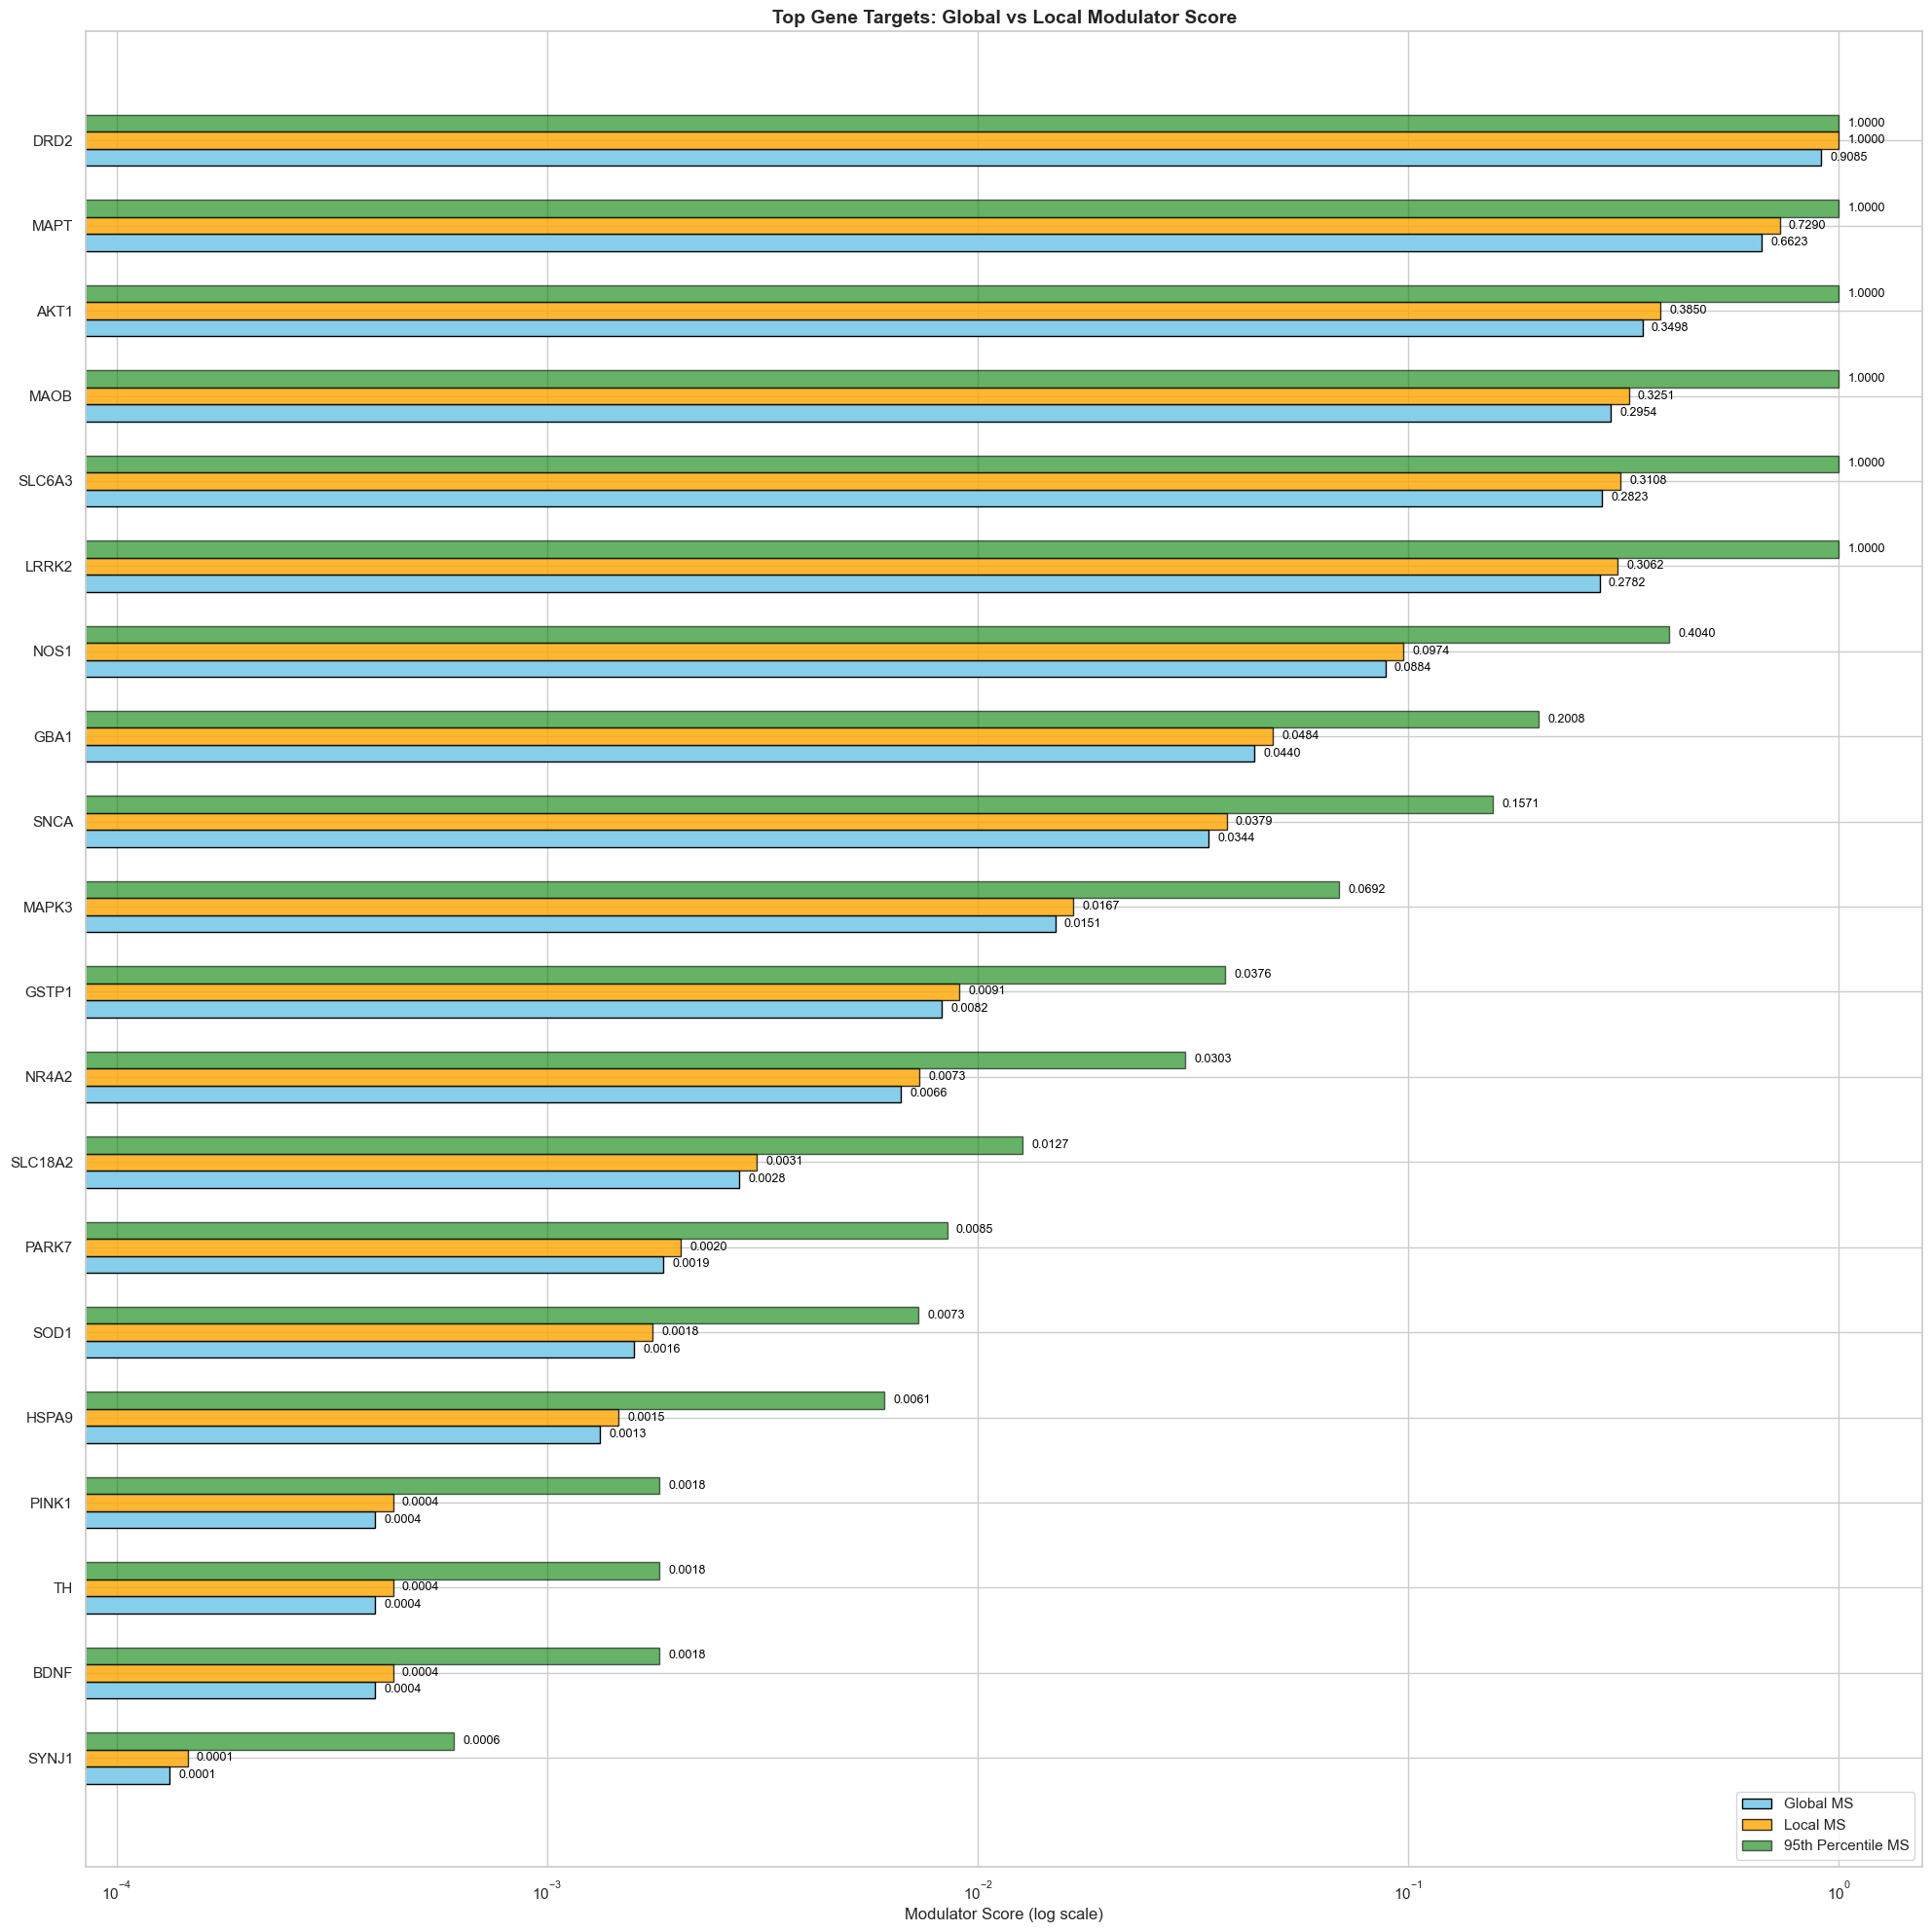

In [7]:
# Sort top N if needed
top_n = 20
plot_df = merged_df.sort_values("ModulatorScore_Global", ascending=False).head(top_n).copy()[::-1]

# Plot setup
plt.figure(figsize=(20, 20))
sns.set(style="whitegrid")

bar_width = 0.2
y_pos = range(len(plot_df))

# Plot bars
plt.barh(y_pos, plot_df["ModulatorScore_Global"], height=bar_width, label="Global MS", color="skyblue", edgecolor="black")
plt.barh([y + bar_width for y in y_pos], plot_df["ModulatorScore_Local"], height=bar_width, label="Local MS", color="orange", alpha=0.8, edgecolor="black")
plt.barh([y + 2 * bar_width for y in y_pos], plot_df["ModulatorScore_q95"], 
         height=bar_width, label="95th Percentile MS", color="green", alpha=0.6, edgecolor="black")

# Add text labels with 4 decimal places and spacing
for i, row in enumerate(plot_df.itertuples()):
    # Global MS label
    if row.ModulatorScore_Global > 0:
        plt.text(row.ModulatorScore_Global * 1.05, i, f"{row.ModulatorScore_Global:.4f}",
                 va='center', fontsize=9, color='black')

    # Local MS label
    if row.ModulatorScore_Local > 0:
        plt.text(row.ModulatorScore_Local * 1.05, i + bar_width, f"{row.ModulatorScore_Local:.4f}",
                 va='center', fontsize=9, color='black')

    # q95 MS label
    if row.ModulatorScore_q95 > 0:
        plt.text(row.ModulatorScore_q95 * 1.05, i + 2 * bar_width, f"{row.ModulatorScore_q95:.4f}",
                 va='center', fontsize=9, color='black')

# Axis, title, legend
plt.xscale("log")
plt.yticks([y + bar_width for y in y_pos], plot_df["Gene"])
plt.xlabel("Modulator Score (log scale)", fontsize=12)
plt.title("Top Gene Targets: Global vs Local Modulator Score", fontsize=14, weight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

#### Interpretation of MS comparison and distribution analysis

This composite figure evaluates the robustness and biological interpretability of the MS applied to PD-associated genes. Three variants of the MS are compared:

1. **Global MS** – scaled by the most modulated human target in ChEMBL
2. **Local MS** – scaled by the most modulated gene within the PD gene list (derived from DisGeNET)
3. **95th Percentile MS** – scaled by the 95th percentile of global modulator counts to mitigate the influence of extreme outliers (e.g., Rab9A)

The consistency between Global and Local MS across the PD gene set demonstrates that these targets are already well-represented among ChEMBL’s most heavily modulated proteins. Genes such as **MAPT**, **DRD2**, and **AKT1** consistently rank highly across all three scoring schemes, indicating strong chemogenomic support for their druggability and potential suitability for repurposing. Importantly, the presence of PD-relevant genes near the global maximum (e.g., MAPT) confirms that the impact of highly screened but biologically irrelevant targets (like Rab9A) on score normalization is minimal in this context. The 95th Percentile MS serves as a conservative alternative, offering resistance to distortion without compromising the original ranking integrity.

Each subplot further supports the conclusion that PD gene modulation is not biased by technical artifacts:

* **(Top left) KDE plot**: The kernel density estimate illustrates that the distribution of modulator counts among PD genes overlaps substantially with the distribution for all human ChEMBL targets. This indicates that PD genes are neither systematically underprofiled nor clustered at the tails of the global distribution.

* **(Top right) ECDF plot**: The empirical cumulative distribution function confirms that the cumulative representation of modulator counts among PD genes closely parallels that of the broader ChEMBL target population, demonstrating a lack of skew or underrepresentation.

* **(Bottom left) Rank vs. Modulator Count scatter plot**: This log–log plot reveals that PD genes are broadly distributed across the global modulator rank spectrum, with key targets like MAPT and DRD2 among the most highly modulated. This underscores the suitability of Global MS for capturing meaningful biological signal within the PD-relevant subset.

* **(Bottom right) Heatmap of MS variants**: The heatmap highlights the concordance across scoring systems. High-ranking genes retain their positions regardless of the scaling method, and lower-ranking genes are not disproportionately affected by the choice of normalization. This reinforces the robustness of Global MS while validating the utility of alternative schemes for specific analytical needs.

Collectively, these visualisations demonstrate that the PD gene set is embedded within the expected druggability landscape of the human proteome. The MS, particularly in its global form, is therefore a reliable and generalisable metric for prioritising repurposable targets, capable of supporting downstream applications across disease contexts without being compromised by dataset-specific artifacts.

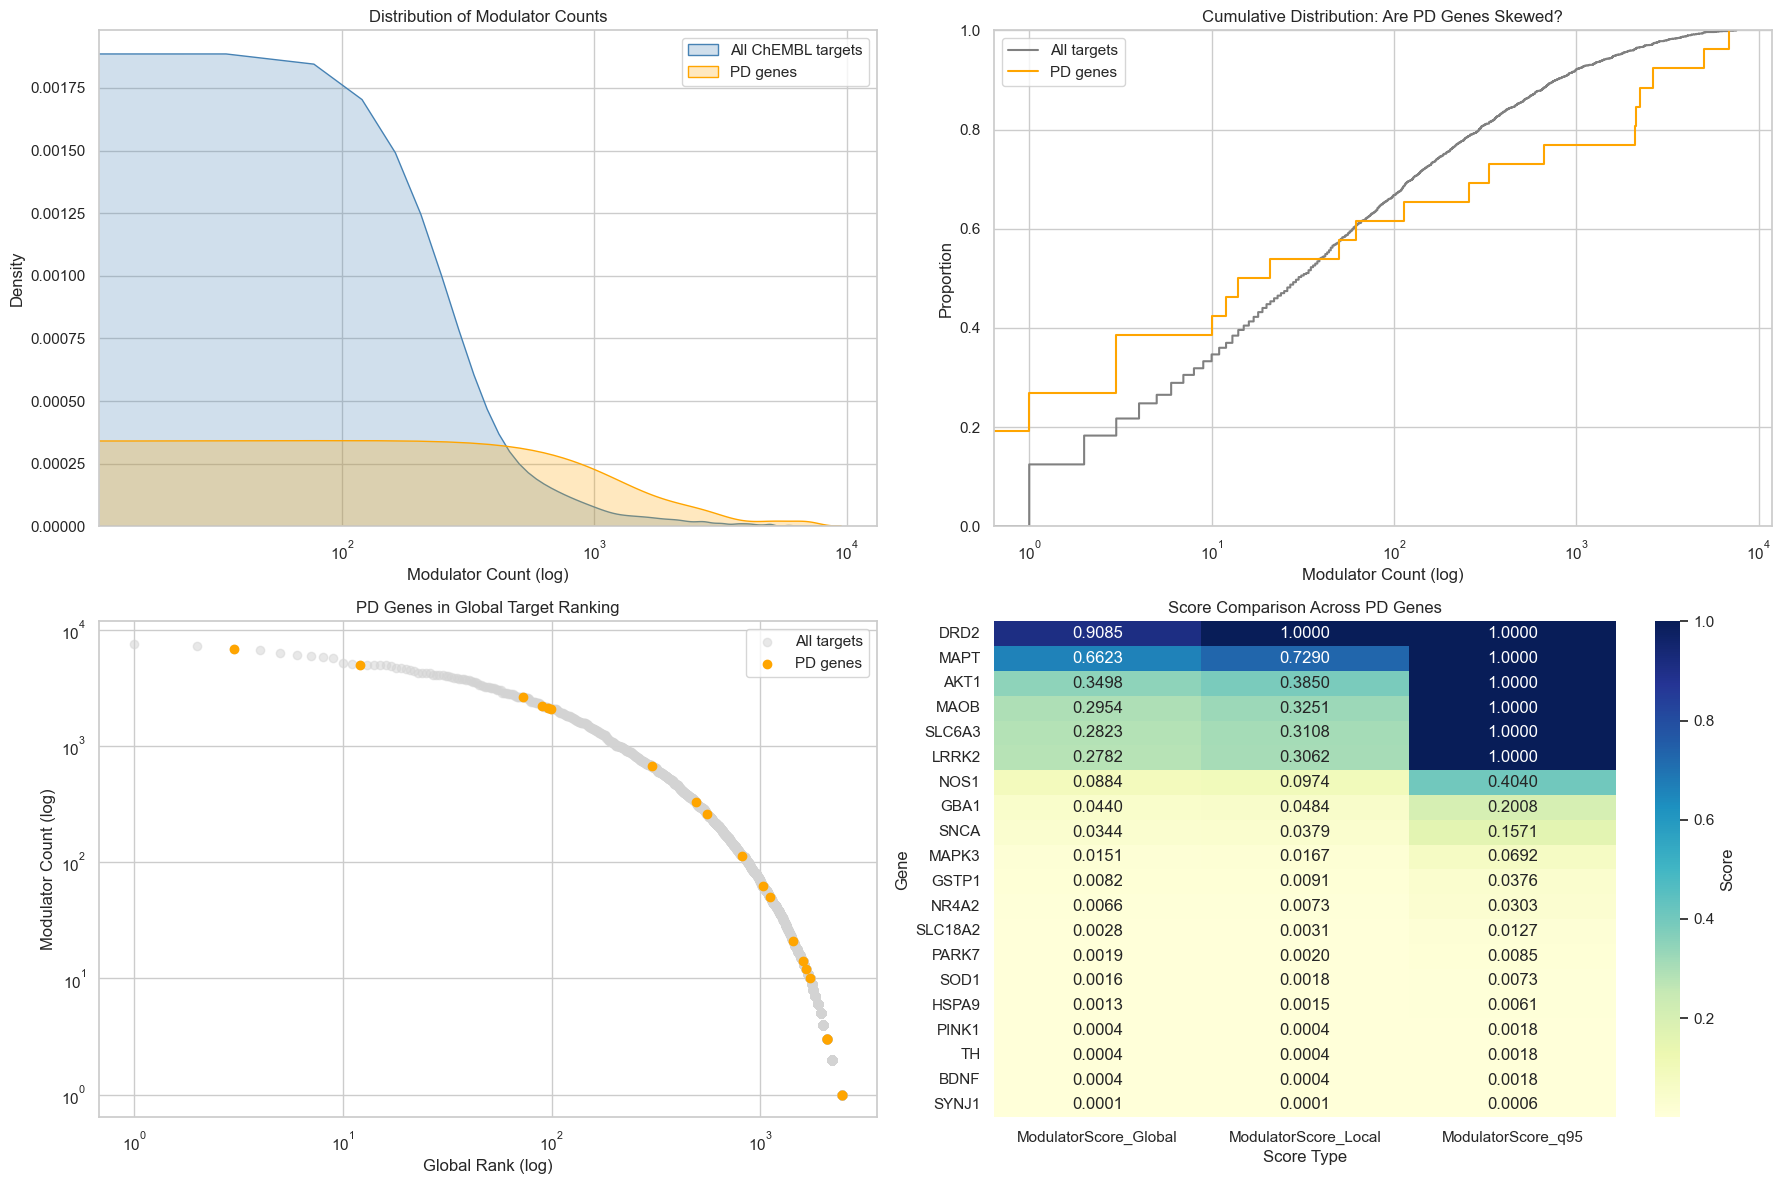

In [8]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# KDE plot
sns.kdeplot(modulatorcount_df["ModulatorCount"], label="All ChEMBL targets",
            fill=True, ax=axes[0, 0], color='steelblue')
sns.kdeplot(merged_df["ModulatorCount"], label="PD genes",
            fill=True, ax=axes[0, 0], color='orange')
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Distribution of Modulator Counts")
axes[0, 0].set_xlabel("Modulator Count (log)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# ECDF plot
sns.ecdfplot(modulatorcount_df["ModulatorCount"], label="All targets",
             ax=axes[0, 1], color="gray")
sns.ecdfplot(merged_df["ModulatorCount"], label="PD genes",
             ax=axes[0, 1], color="orange")
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Cumulative Distribution: Are PD Genes Skewed?")
axes[0, 1].set_xlabel("Modulator Count (log)")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].legend()

# Scatter plot of rank vs count
modulatorcount_df["Rank"] = modulatorcount_df["ModulatorCount"].rank(ascending=False)
axes[1, 0].scatter(modulatorcount_df["Rank"], modulatorcount_df["ModulatorCount"],
                   color='lightgray', alpha=0.5, label="All targets")
pd_ranks = modulatorcount_df[modulatorcount_df["ChEMBLTargetID"].isin(merged_df["ChEMBLTargetID"])]
axes[1, 0].scatter(pd_ranks["Rank"], pd_ranks["ModulatorCount"],
                   color='orange', label="PD genes")
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("Global Rank (log)")
axes[1, 0].set_ylabel("Modulator Count (log)")
axes[1, 0].set_title("PD Genes in Global Target Ranking")
axes[1, 0].legend()

# Heatmap of scores
plot_df = merged_df.sort_values("ModulatorScore_Global", ascending=False).head(20).copy()
score_data = plot_df[["ModulatorScore_Global", "ModulatorScore_Local", "ModulatorScore_q95"]]
sns.heatmap(score_data, annot=True, fmt=".4f", cmap="YlGnBu", ax=axes[1, 1],
            yticklabels=plot_df["Gene"], cbar_kws={'label': 'Score'})
axes[1, 1].set_title("Score Comparison Across PD Genes")
axes[1, 1].set_xlabel("Score Type")
axes[1, 1].set_ylabel("Gene")

plt.tight_layout()
plt.show()


#### Biologic Drug Score (BDS) SKIP...

This section queries the ChEMBL database to compute a **Biologic Drug Score (BDS)** for each target. While the Small Molecule Score (SMS) relies on **activity data**, which is available only for small-molecule compounds, many **biologic drugs (e.g. antibodies, oligonucleotides, proteins)** do **not** have pChEMBL values and would otherwise be missed in targetability assessments.

To address this gap, BDS evaluates therapeutic relevance based on biologic drugs linked to each target and their **clinical approval status**. The scoring scheme is based on the highest clinical phase of biologic drugs targeting a given protein:

| Criteria                                     | Score |
| -------------------------------------------- | ----- |
| Phase 4 drug, not withdrawn                  | 1.0   |
| Phase 2 or 3 drug, not withdrawn             | 0.7   |
| Phase 1 drug                                 | 0.3   |
| Withdrawn, preclinical, or no biologic drugs | 0.0   |

The resulting `biologics_df` contains one row per target with a `BiologicDrugScore` between `0.0` and `1.0`.

In [9]:
sql= """
SELECT
    TARGET_DICTIONARY.chembl_id AS ChEMBLTargetID,
    MAX(
        CASE
            WHEN MOLECULE_DICTIONARY.max_phase = 4 AND MOLECULE_DICTIONARY.withdrawn_flag = 0 THEN 1.0
            WHEN MOLECULE_DICTIONARY.max_phase IN (2,3) AND MOLECULE_DICTIONARY.withdrawn_flag = 0 THEN 0.7
            WHEN MOLECULE_DICTIONARY.max_phase = 1 THEN 0.3
            ELSE 0.0
        END
    ) AS BiologicDrugScore
FROM DRUG_MECHANISM
JOIN MOLECULE_DICTIONARY ON DRUG_MECHANISM.molregno = MOLECULE_DICTIONARY.molregno
JOIN TARGET_DICTIONARY ON DRUG_MECHANISM.tid = TARGET_DICTIONARY.tid
WHERE MOLECULE_DICTIONARY.molecule_type NOT IN ('Small molecule', 'Unknown')
  AND TARGET_DICTIONARY.target_type = 'SINGLE PROTEIN'
GROUP BY TARGET_DICTIONARY.chembl_id
"""

biologics_df = chembl_downloader.query(sql)
biologics_df

,ChEMBLTargetID,BiologicDrugScore
0,CHEMBL1075113,0.7
1,CHEMBL1075153,0.7
2,CHEMBL1075259,0.7
3,CHEMBL1075313,0.7
4,CHEMBL1169600,1.0
...,...,...
412,CHEMBL5966,1.0
413,CHEMBL5989,0.7
414,CHEMBL6024,0.7
415,CHEMBL6152,0.7


#### Creating a normalised Crystal Structure Score (CSS)

The **Crystal Structure Score (CSS)** is designed to quantify how structurally "visible" or experimentally accessible a protein target is for structure-based drug discovery. Structural availability plays a key role in medicinal chemistry and computational workflows, especially for **structure-based virtual screening**, **ligand docking**, and **binding site modelling**. Targets with solved crystal structures at sufficient resolution enable more confident binding predictions and atomic-level interaction modelling, whereas structurally obscure proteins represent a persistent bottleneck in rational drug design.

To capture this aspect, CSS aggregates all **X-ray crystallography structures** from the Protein Data Bank (PDB), mapped to human UniProt identifiers using the SIFTS resource. Only structures resolved at **≤2.5 Å** are considered—this threshold reflects the **community standard** for coordinate-level reliability in small-molecule docking and active-site modelling. It is widely adopted across structure-guided drug discovery pipelines to ensure geometric accuracy and reproducibility <sup>\[3]</sup>.

For each gene, the number of qualifying high-resolution structures is counted and converted into a normalised CSS. Three variants are computed:

* **Global score**: normalised against the **maximum count across all human targets**, so the most structurally profiled protein receives **CSS = 1.0**.
* **Quantile-based score**: normalised relative to the **95th percentile**, to reduce the effect of extreme outliers.
* **Local score**: normalised across only the current target list, providing relative visibility within a study-specific subset.

CSS complements the MS, helping identify structurally rich targets that may otherwise be neglected due to sparse bioactivity data. It is especially valuable for **structure-enabled repositioning** strategies such as fragment-based design, ligand elaboration, and machine learning-based structure completion.

> That said, the absence of structure data does not equate to non-druggability. It may reflect historical neglect, poor expression, or technical barriers. Nonetheless, CSS offers a transparent measure of **current structural opportunity space**, aiding in target prioritisation for computational drug discovery.

<sup>\[3]: M. Burley, C. Berman, H. M. Goodsell, G. J. Kurisu, R. Nakamura, S. K. Lawson, A. J. Dutta and D. S. Rose, *Nucleic Acids Res.*, 2021, **49**, D437–D451, DOI: [10.1093/nar/gkaa1038](https://doi.org/10.1093/nar/gkaa1038).</sup>

In [10]:
data_dir = "../data"
sifts_url = "https://ftp.ebi.ac.uk/pub/databases/msd/sifts/flatfiles/tsv/pdb_chain_uniprot.tsv.gz"
pdb_url = "https://ftp.ebi.ac.uk/pub/databases/pdb/derived_data/index/entries.idx"
sifts_path = os.path.join(data_dir, "pdb_chain_uniprot.tsv.gz")
sifts_tsv = os.path.join(data_dir, "pdb_chain_uniprot.tsv")
pdb_path = os.path.join(data_dir, "entries.idx")

def download_file(url, path):
    if not os.path.exists(path):
        print(f"Downloading: {path}")
        r = requests.get(url, stream=True)
        with open(path, "wb") as f:
            shutil.copyfileobj(r.raw, f)

download_file(sifts_url, sifts_path)
download_file(pdb_url, pdb_path)

if not os.path.exists(sifts_tsv):
    print("Unzipping SIFTS...")
    with gzip.open(sifts_path, "rb") as f_in, open(sifts_tsv, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)

# --- Read SIFTS and PDB metadata ---
print("Reading SIFTS...")
sifts = pd.read_csv(sifts_tsv, sep="\t", skiprows=1, usecols=["PDB", "SP_PRIMARY"])
sifts = sifts.rename(columns={"PDB": "structureId", "SP_PRIMARY": "UniProt"})
sifts = sifts.dropna().drop_duplicates()
sifts["structureId"] = sifts["structureId"].str.upper().str.strip()
print("Reading PDB metadata...")
meta = pd.read_csv(
    pdb_path, sep="\t", skiprows=2,
    names=["IDCODE", "HEADER", "ACCESSION_DATE", "COMPOUND", "SOURCE", "AUTHOR_LIST", "RESOLUTION", "EXPDTA"],
    dtype=str
)
meta["RESOLUTION"] = pd.to_numeric(meta["RESOLUTION"], errors="coerce")
meta["IDCODE"] = meta["IDCODE"].str.upper().str.strip()
meta = meta[
    (meta["EXPDTA"].str.strip() == "X-RAY DIFFRACTION") &
    (meta["RESOLUTION"].notna()) &
    (meta["RESOLUTION"] <= 2.5)
]
meta = meta.rename(columns={"IDCODE": "structureId"})
print("Filtered high-resolution structures:", len(meta))

# --- Count high-res structures per UniProt ---
print("Joining SIFTS and metadata...")
df = pd.merge(sifts, meta, on="structureId", how="inner")
counts = df.groupby("UniProt")["structureId"].nunique().reset_index()
counts = counts.rename(columns={"structureId": "CrystalStructureCount"})
counts.to_csv(os.path.join(data_dir, "csas_all_uniprot.csv"), index=False)

# --- Filter to human proteins ---
def fetch_human_uniprots():
    url = "https://rest.uniprot.org/uniprotkb/stream?query=organism_id:9606&format=tsv&fields=accession"
    r = requests.get(url)
    return set(r.text.strip().split("\n")[1:])
print("Filtering to human UniProt IDs...")
human_uniprots = fetch_human_uniprots()
counts = counts[counts["UniProt"].isin(human_uniprots)]

# --- Compute scores ---
global_max = counts["CrystalStructureCount"].max()
q95 = counts["CrystalStructureCount"].quantile(0.95)
counts["CrystalScore_Global"] = counts["CrystalStructureCount"] / global_max
counts["CrystalScore_q95"] = (counts["CrystalStructureCount"] / q95).clip(upper=1.0)
counts.to_csv(os.path.join(data_dir, "global_crystal_structure_scores.csv"), index=False)
print(f"\nDone. Global max: {global_max}, 95th percentile: {q95:.1f}")

# --- Merge with merged_df (assumed preloaded) ---
exploded = merged_df.copy()
exploded["UniProt"] = exploded["UniProt"].str.split(",").apply(lambda x: [u.strip() for u in x])
exploded = exploded.explode("UniProt").drop(columns=["UniProtList"], errors="ignore")
merged = exploded.merge(counts, on="UniProt", how="left")
agg = merged.groupby("Gene").agg({
    "CrystalStructureCount": "max",
    "CrystalScore_Global": "max",
    "CrystalScore_q95": "max"
}).reset_index()
local_max = agg["CrystalStructureCount"].max()
agg["CrystalScore_Local"] = agg["CrystalStructureCount"] / local_max
final_df = merged_df.drop(columns=["UniProtList"], errors="ignore")
final_df = final_df.merge(agg, on="Gene", how="left")
final_df

Reading SIFTS...
Reading PDB metadata...
Filtered high-resolution structures: 143241
Joining SIFTS and metadata...
Filtering to human UniProt IDs...

Done. Global max: 1092, 95th percentile: 31.0


,Gene,ChEMBLTargetID,UniProt,GeneFullName,PathwayIDs,PathwayNames,ProteinClass,ScoreGDA,geneNcbiID,geneNcbiType,ModulatorCount,ModulatorScore_Global,ModulatorScore_q95,ModulatorScore_Local,CrystalStructureCount,CrystalScore_Global,CrystalScore_q95,CrystalScore_Local
0,VPS35,CHEMBL2216744,Q96QK1,VPS35 retromer complex component,R-HSA-162582,Signal Transduction,Transporter,1.0,55737,protein-coding,0.0,0.000000,0.000000,0.000000,2.0,0.001832,0.064516,0.018349
1,LRRK2,CHEMBL1075104,"Q17RV3,Q5S007",leucine rich repeat kinase 2,R-HSA-162582,Signal Transduction,Kinase,1.0,120892,protein-coding,2095.0,0.278220,1.000000,0.306242,8.0,0.007326,0.258065,0.073394
2,PARK7,CHEMBL5169188,"Q99497,V9HWC2",Parkinsonism associated deglycase,"R-HSA-392499,R-HSA-9612973","Metabolism of proteins,Autophagy",Enzyme,1.0,11315,protein-coding,14.0,0.001859,0.008493,0.002046,82.0,0.075092,1.000000,0.752294
3,NR4A2,CHEMBL5002,"Q53EL4,P43354,F1D8N6",nuclear receptor subfamily 4 group A member 2,"R-HSA-392499,R-HSA-74160","Metabolism of proteins,Gene expression (Transc...",Nuclear receptor,1.0,4929,protein-coding,50.0,0.006640,0.030331,0.007309,3.0,0.002747,0.096774,0.027523
4,BDNF,CHEMBL4523205,"A0A0E3SU01,P23560",brain derived neurotrophic factor,"R-HSA-162582,R-HSA-1643685,R-HSA-74160","Signal Transduction,Disease,Gene expression (T...",Signaling,1.0,627,protein-coding,3.0,0.000398,0.001820,0.000439,1.0,0.000916,0.032258,0.009174
5,MAPT,CHEMBL1293224,"B3KTM0,P10636",microtubule associated protein tau,"R-HSA-112316,R-HSA-168256,R-HSA-5357801","Neuronal System,Immune System,Programmed Cell ...",,1.0,4137,protein-coding,4987.0,0.662284,1.000000,0.728987,42.0,0.038462,1.000000,0.385321
6,MAOB,CHEMBL2039,"B7Z242,P27338",monoamine oxidase B,R-HSA-1430728,Metabolism,,1.0,4129,protein-coding,2224.0,0.295352,1.000000,0.325099,50.0,0.045788,1.000000,0.458716
7,PINK1,CHEMBL3337330,Q9BXM7,PTEN induced kinase 1,"R-HSA-74160,R-HSA-9612973","Gene expression (Transcription),Autophagy",Kinase,1.0,65018,protein-coding,3.0,0.000398,0.001820,0.000439,NaN,NaN,NaN,NaN
8,SNCA,CHEMBL6152,"P37840,H6UYS5",synuclein alpha,"R-HSA-168256,R-HSA-392499","Immune System,Metabolism of proteins",Transporter,1.0,6622,protein-coding,259.0,0.034396,0.157113,0.037860,14.0,0.012821,0.451613,0.128440
9,GBA1,CHEMBL2179,"B7Z6S9,P04062,A0A068F658",glucosylceramidase beta 1,"R-HSA-1430728,R-HSA-392499","Metabolism,Metabolism of proteins",,1.0,2629,protein-coding,331.0,0.043958,0.200789,0.048385,47.0,0.043040,1.000000,0.431193


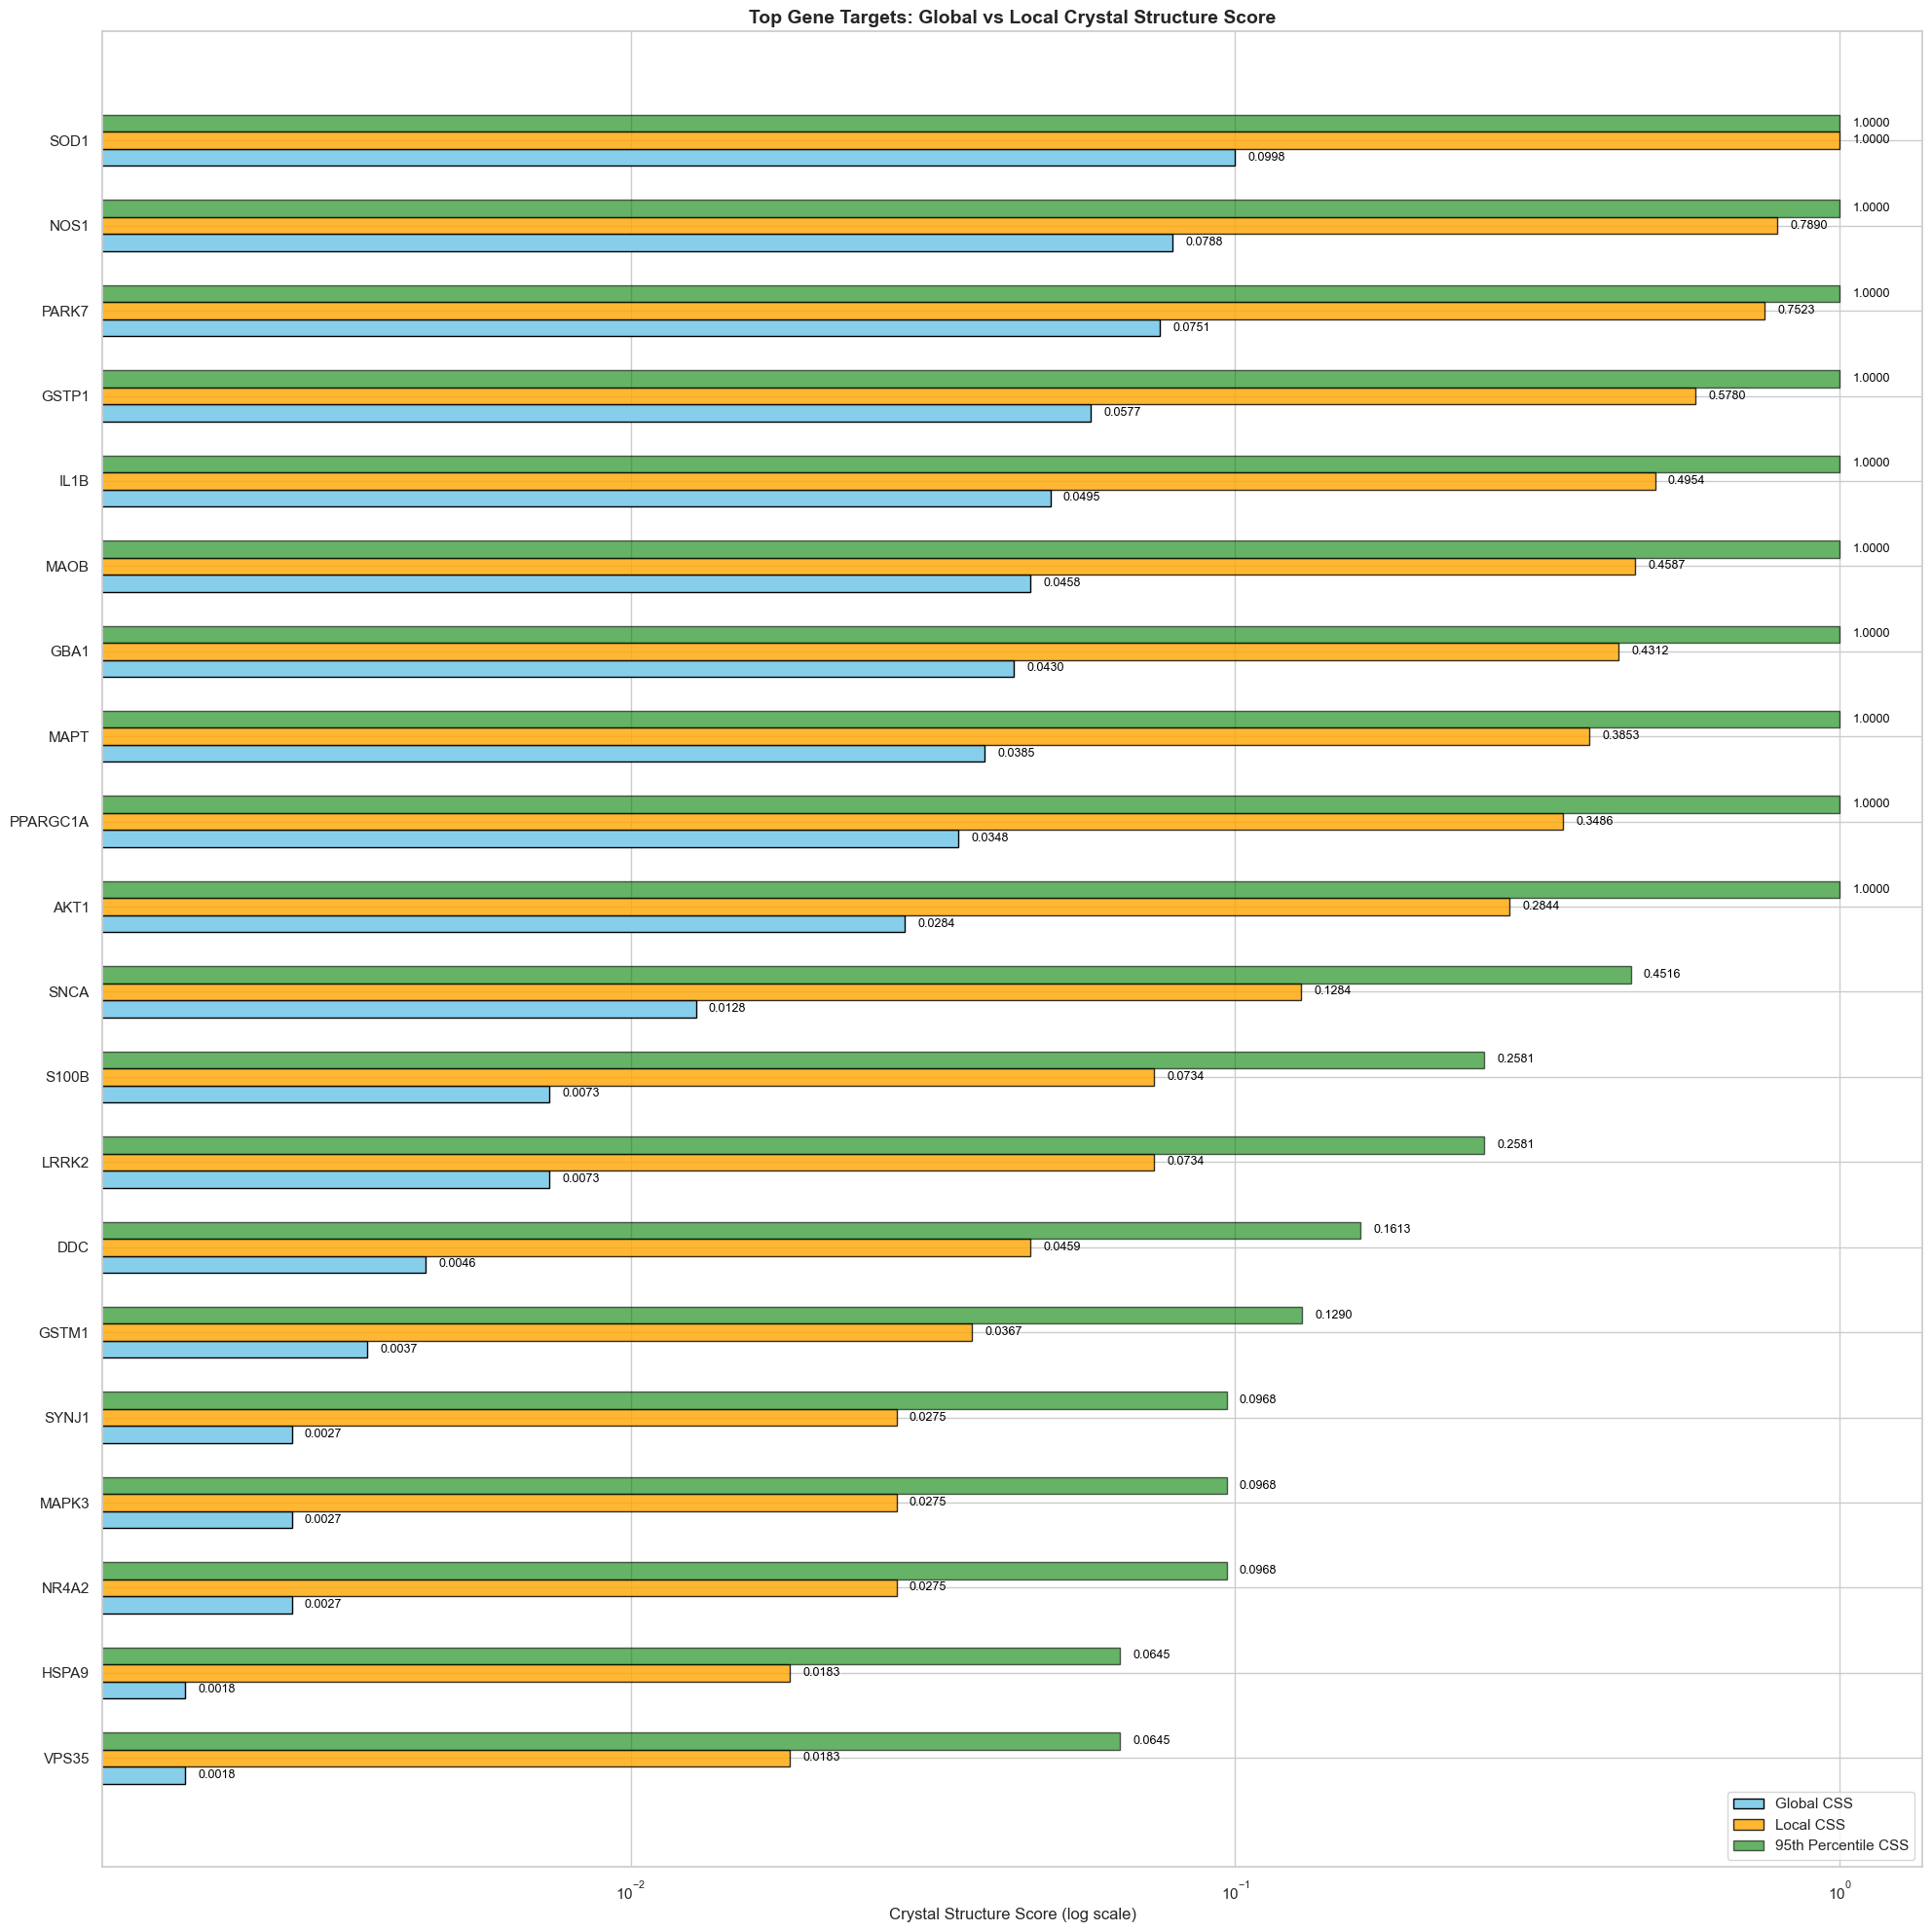

In [11]:
# --- Sort top N genes by Global Crystal Score ---
top_n = 20
plot_df = final_df.sort_values("CrystalScore_Global", ascending=False).head(top_n).copy()[::-1]

# --- Plot setup ---
plt.figure(figsize=(20, 20))
sns.set(style="whitegrid")

bar_width = 0.2
y_pos = range(len(plot_df))

# --- Bar plots for Global, Local, and 95th percentile CSC ---
plt.barh(y_pos, plot_df["CrystalScore_Global"], height=bar_width, label="Global CSS", color="skyblue", edgecolor="black")
plt.barh([y + bar_width for y in y_pos], plot_df["CrystalScore_Local"], height=bar_width, label="Local CSS", color="orange", alpha=0.8, edgecolor="black")
plt.barh([y + 2 * bar_width for y in y_pos], plot_df["CrystalScore_q95"], height=bar_width, label="95th Percentile CSS", color="green", alpha=0.6, edgecolor="black")

# --- Text labels ---
for i, row in enumerate(plot_df.itertuples()):
    if row.CrystalScore_Global > 0:
        plt.text(row.CrystalScore_Global * 1.05, i, f"{row.CrystalScore_Global:.4f}", va='center', fontsize=9, color='black')
    if row.CrystalScore_Local > 0:
        plt.text(row.CrystalScore_Local * 1.05, i + bar_width, f"{row.CrystalScore_Local:.4f}", va='center', fontsize=9, color='black')
    if row.CrystalScore_q95 > 0:
        plt.text(row.CrystalScore_q95 * 1.05, i + 2 * bar_width, f"{row.CrystalScore_q95:.4f}", va='center', fontsize=9, color='black')

# --- Axis, labels, legend ---
plt.xscale("log")
plt.yticks([y + bar_width for y in y_pos], plot_df["Gene"])
plt.xlabel("Crystal Structure Score (log scale)", fontsize=12)
plt.title("Top Gene Targets: Global vs Local Crystal Structure Score", fontsize=14, weight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

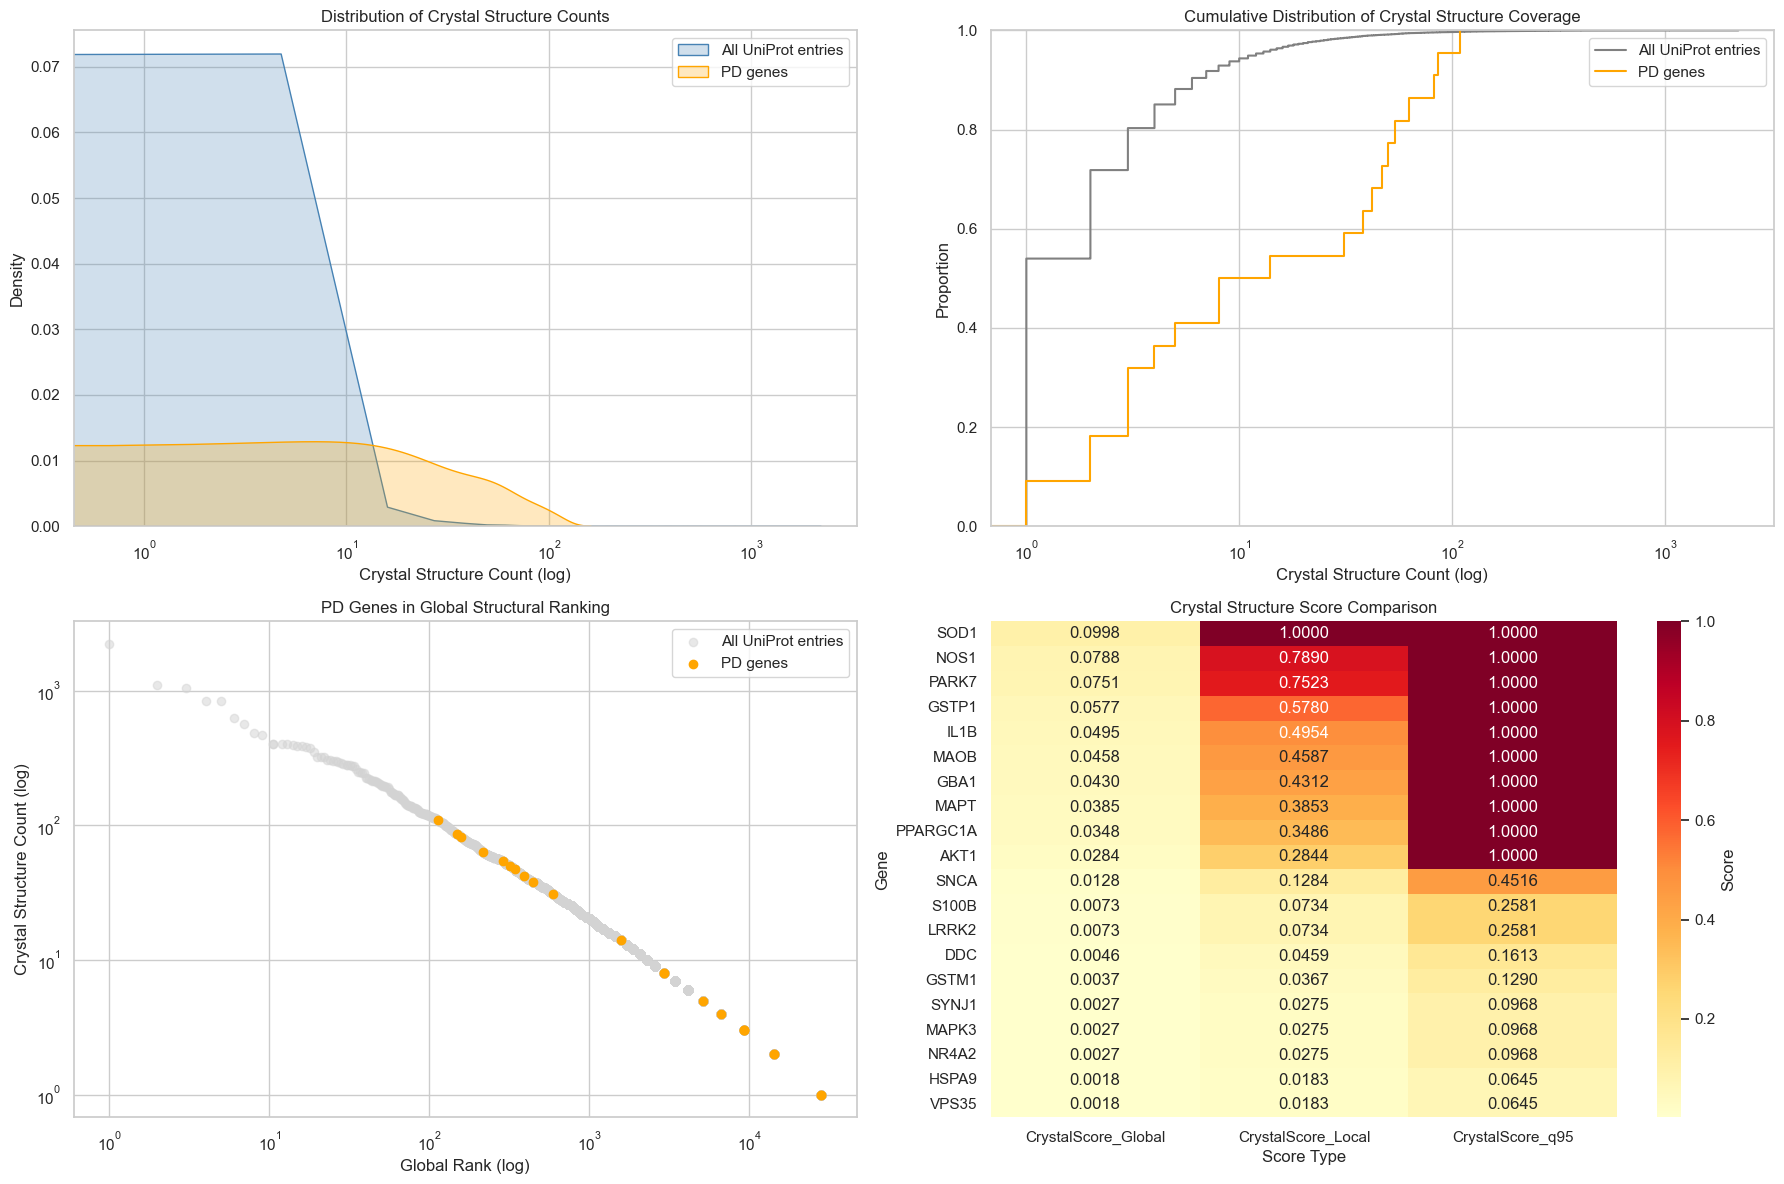

In [12]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# KDE plot: all UniProt IDs vs genes in final_df
csas_all = pd.read_csv("../data/csas_all_uniprot.csv")
sns.kdeplot(csas_all["CrystalStructureCount"], label="All UniProt entries",
            fill=True, ax=axes[0, 0], color='steelblue')
sns.kdeplot(final_df["CrystalStructureCount"], label="PD genes",
            fill=True, ax=axes[0, 0], color='orange')
axes[0, 0].set_xscale("log")
axes[0, 0].set_title("Distribution of Crystal Structure Counts")
axes[0, 0].set_xlabel("Crystal Structure Count (log)")
axes[0, 0].set_ylabel("Density")
axes[0, 0].legend()

# ECDF plot
sns.ecdfplot(csas_all["CrystalStructureCount"], label="All UniProt entries",
             ax=axes[0, 1], color="gray")
sns.ecdfplot(final_df["CrystalStructureCount"], label="PD genes",
             ax=axes[0, 1], color="orange")
axes[0, 1].set_xscale("log")
axes[0, 1].set_title("Cumulative Distribution of Crystal Structure Coverage")
axes[0, 1].set_xlabel("Crystal Structure Count (log)")
axes[0, 1].set_ylabel("Proportion")
axes[0, 1].legend()

# Scatter: rank vs count
csas_all["Rank"] = csas_all["CrystalStructureCount"].rank(ascending=False)
final_csas = csas_all[csas_all["UniProt"].isin(final_df["UniProt"].str.split(",").explode())]
axes[1, 0].scatter(csas_all["Rank"], csas_all["CrystalStructureCount"],
                   color='lightgray', alpha=0.5, label="All UniProt entries")
axes[1, 0].scatter(final_csas["Rank"], final_csas["CrystalStructureCount"],
                   color='orange', label="PD genes")
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("Global Rank (log)")
axes[1, 0].set_ylabel("Crystal Structure Count (log)")
axes[1, 0].set_title("PD Genes in Global Structural Ranking")
axes[1, 0].legend()

# Heatmap
plot_df = final_df.sort_values("CrystalScore_Global", ascending=False).head(20).copy()
score_data = plot_df[["CrystalScore_Global", "CrystalScore_Local", "CrystalScore_q95"]]
sns.heatmap(score_data, annot=True, fmt=".4f", cmap="YlOrRd", ax=axes[1, 1],
            yticklabels=plot_df["Gene"], cbar_kws={'label': 'Score'})
axes[1, 1].set_title("Crystal Structure Score Comparison")
axes[1, 1].set_xlabel("Score Type")
axes[1, 1].set_ylabel("Gene")

plt.tight_layout()
plt.show()

#### Interpretation of CSS comparison and structural availability patterns

This composite figure set offers a comprehensive assessment of the **Crystal Structure Score (CSS)** across PD-associated gene targets, benchmarking them against the broader structural proteome. The CSS, which quantifies the density of high-resolution (≤2.5 Å) crystal structures available for a target, acts as a proxy for the structural "visibility" of proteins in structure-based drug discovery workflows. The analysis includes three scoring variants—**Global**, **Local**, and **95th Percentile CSS**—to highlight different normalisation strategies for interpreting structural coverage.

The bar plot (Figure 1) reveals a high level of consistency between Global and Local CSS scores for top PD gene targets, with many ranking near the top of the global structural distribution. Proteins such as **SOD1**, **PARK7**, **GSTP1**, and **NOS1** consistently show high CSS across all metrics, underscoring their amenability to **structure-guided design**, docking, or fragment-based screening. The Global CSS provides a rigorous, proteome-wide comparison, while the Local CSS and 95th Percentile CSS mitigate skew from structurally “overstudied” targets (e.g., SOD1, HSP90 homologues) and offer a more nuanced comparison within disease-focused gene sets. 

The **heatmap (Figure 2, bottom right)** further illustrates the convergence of these three scoring schemes. While minor differences exist—especially for mid-ranking targets like **S100B**, **GSTM1**, and **SYNJ1**—the relative rankings remain largely consistent, suggesting that even conservative normalisation (e.g., q95) preserves the biologically meaningful signal. Notably, nearly all top-ranking PD genes achieve a **CSS\_q95 = 1.0**, indicating their structural saturation relative to the broader proteome. Nearly all top-ranking PD genes achieve a CSS_q95 score of 1.0, meaning they are structurally well-represented compared to the top 5% of all human targets in the proteome.

**Distribution plots (Figure 2, top row)** demonstrate the broader structural landscape. The KDE (top left) shows that PD-associated proteins are neither structurally neglected nor overrepresented, but instead span a wide range of structural coverage, mirroring the distribution of all human UniProt entries with crystal data. This suggests **no inherent structural bias** in the PD gene subset. The ECDF (top right) provides complementary insight: although a slight rightward shift is seen (i.e., fewer PD genes reach the upper tail of structural density), the overall trajectory indicates that **PD targets are structurally accessible**, especially in comparison to the “dark proteome”.

Finally, the **rank plot (bottom left)** positions PD genes within the global crystal structure rank distribution. Genes like **SOD1** and **NOS1** fall within the top decile, reinforcing their tractability for 3D-based drug design. Conversely, structurally underrepresented targets such as **VPS35** or **HSPA9** remain within the detectable range but would likely benefit from **homology modelling** or **AI-predicted structures** (e.g., AlphaFold) to bridge structural gaps.

Together, these visualisations validate CSS as a **robust, biologically interpretable metric** for prioritising drug targets based on structural readiness. The use of high-resolution X-ray data ensures reliability in downstream applications, and the agreement across CSS variants supports its generalisability across disease contexts and study designs.

/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/2883686510.py:70: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/2883686510.py:202: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  ax.legend(*scatter.legend_elements(), title="Category", labels=legend_labels)
/Users/florionpeni/anaconda3/envs/compdream/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/2883686510.py:217: MatplotlibDeprecationWarning: You have mixed posi

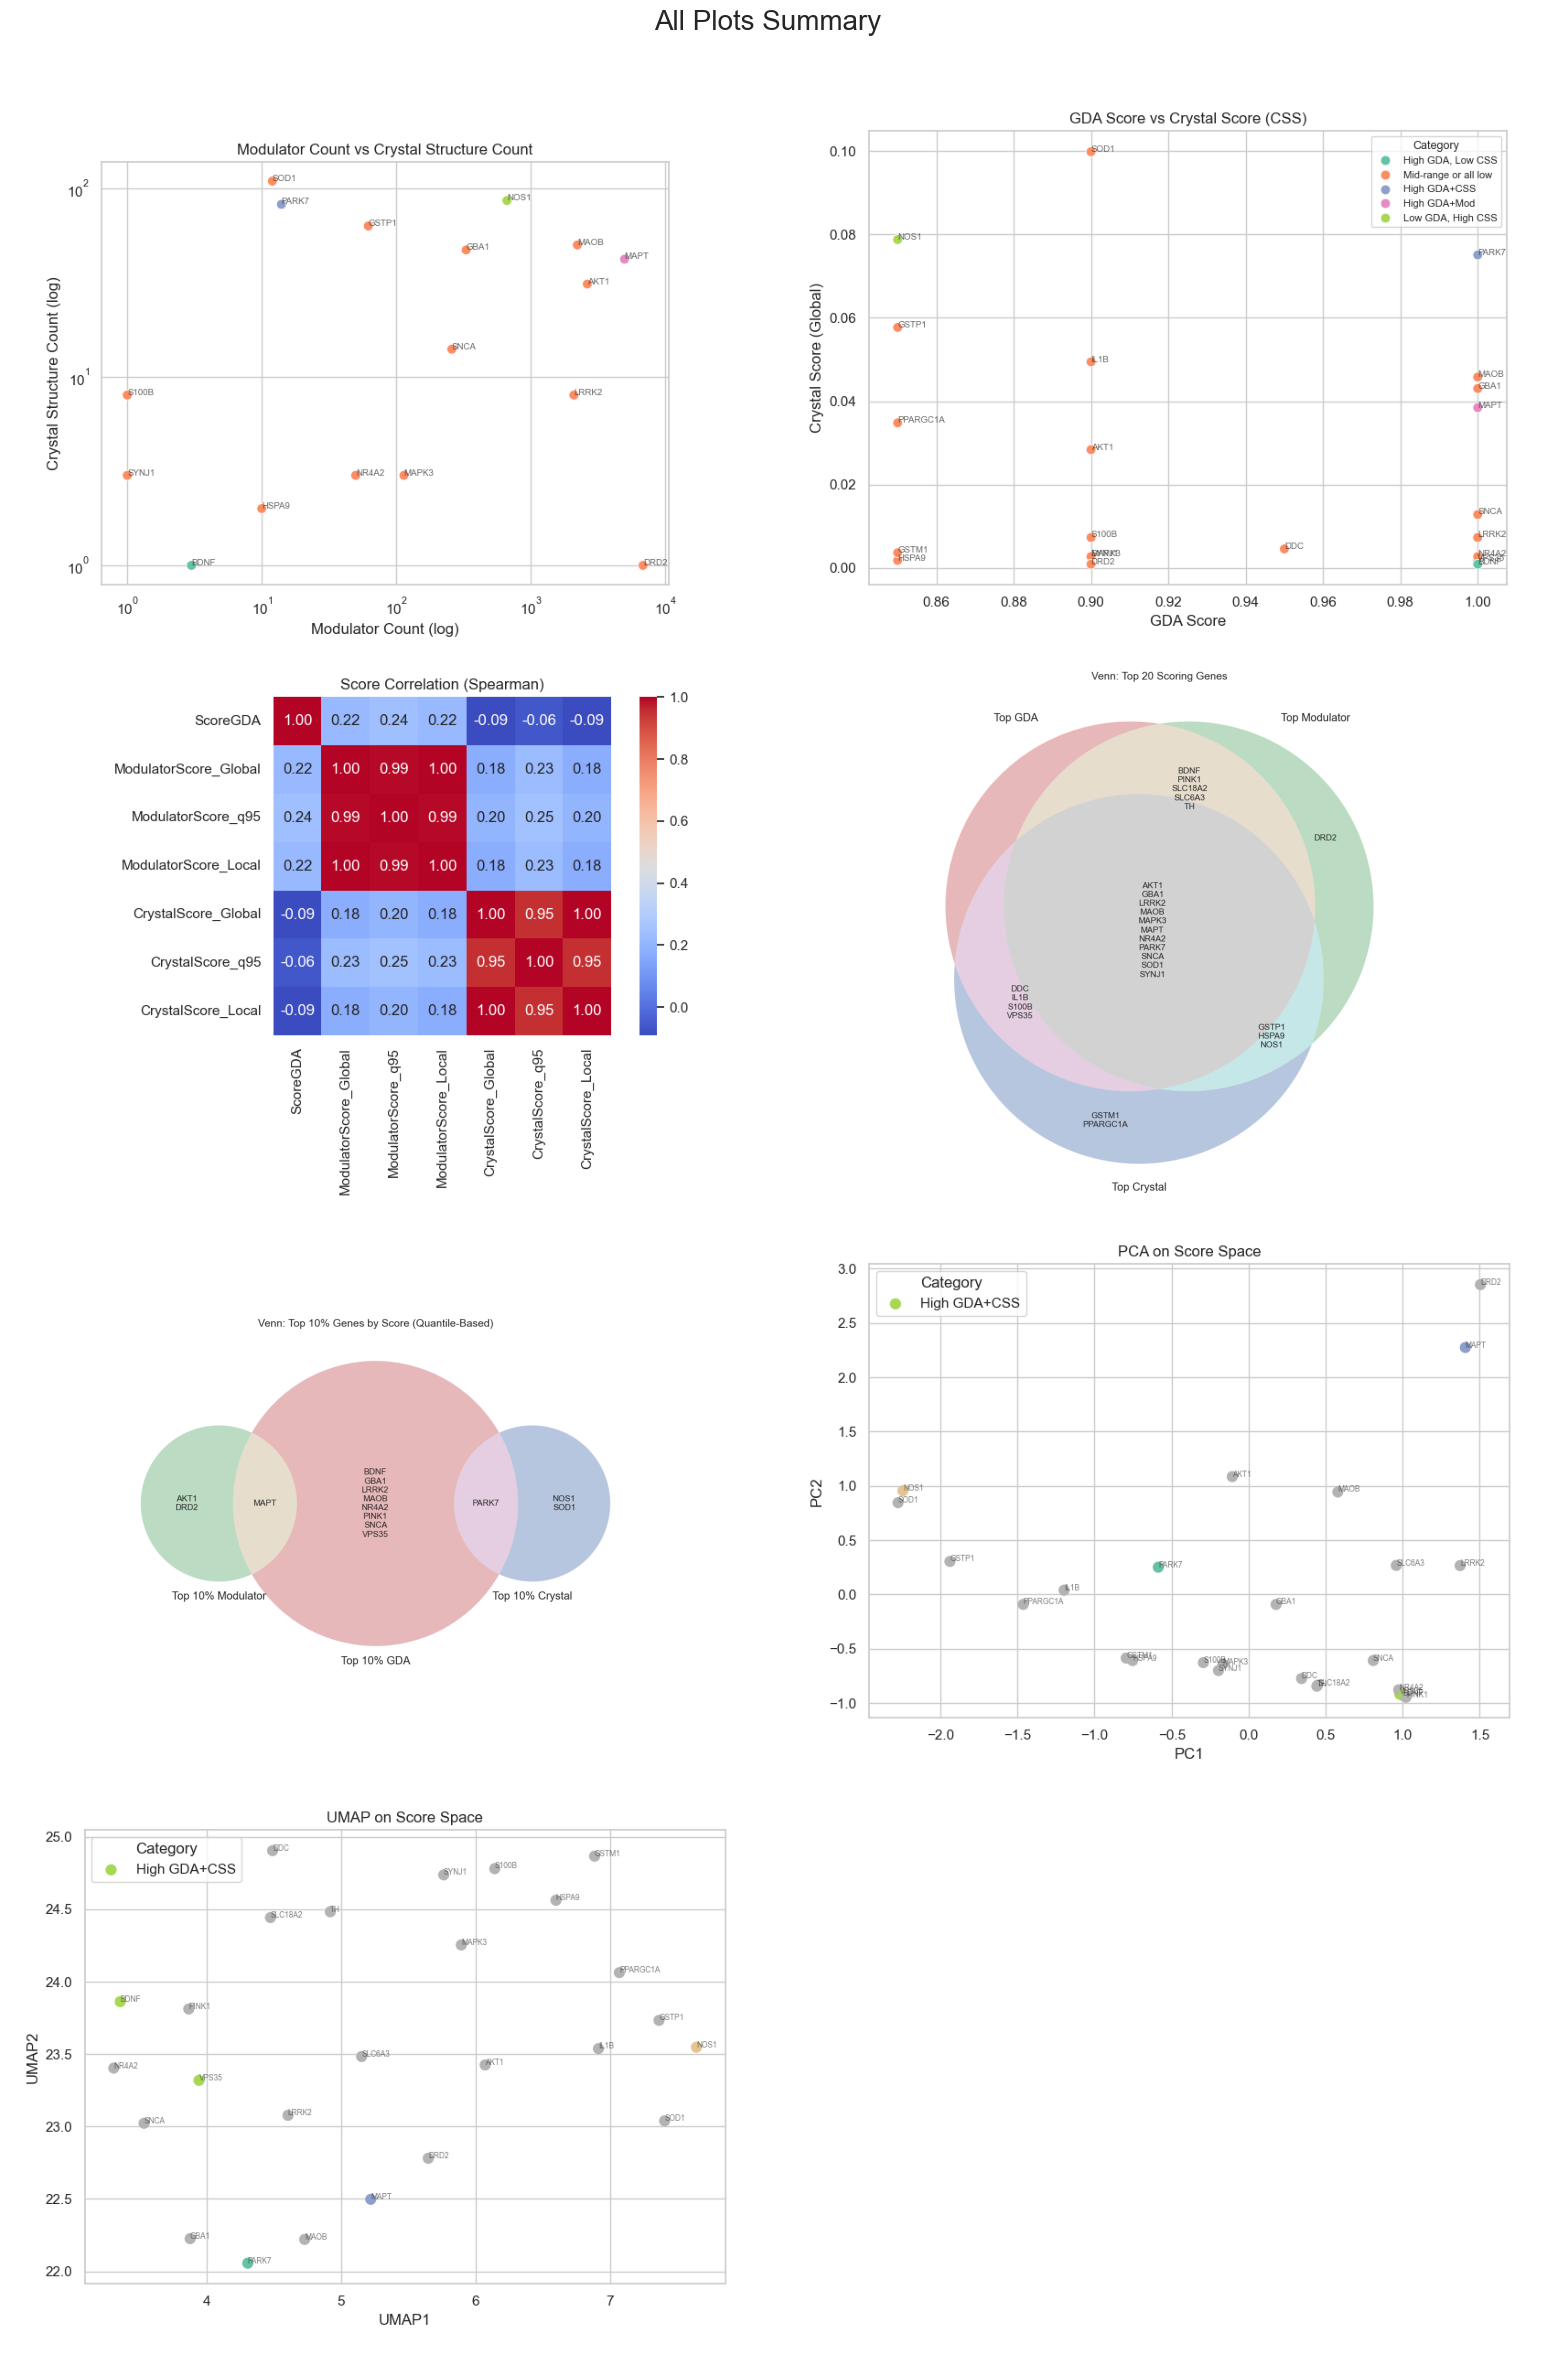

In [13]:
# === Create output folder ===
os.makedirs("plots", exist_ok=True)

# === Ensure numeric scores ===
score_cols = ["ScoreGDA", "ModulatorScore_Global", "CrystalScore_Global"]
final_df[score_cols] = final_df[score_cols].apply(pd.to_numeric, errors="coerce")

# === Define quantile thresholds ===
q_high = 0.9
q_low = 0.1

gda_high = final_df["ScoreGDA"].quantile(q_high)
gda_low = final_df["ScoreGDA"].quantile(q_low)
mod_high = final_df["ModulatorScore_Global"].quantile(q_high)
mod_low = final_df["ModulatorScore_Global"].quantile(q_low)
css_high = final_df["CrystalScore_Global"].quantile(q_high)
css_low = final_df["CrystalScore_Global"].quantile(q_low)

def tag_gene(row):
    gda = row["ScoreGDA"]
    mod = row["ModulatorScore_Global"]
    css = row["CrystalScore_Global"]
    if gda >= gda_high and mod >= mod_high and css >= css_high:
        return "All High"
    elif gda >= gda_high and mod >= mod_high:
        return "High GDA+Mod"
    elif gda >= gda_high and css >= css_high:
        return "High GDA+CSS"
    elif mod >= mod_high and css >= css_high:
        return "High Mod+CSS"
    elif gda >= gda_high and css <= css_low:
        return "High GDA, Low CSS"
    elif gda <= gda_low and css >= css_high:
        return "Low GDA, High CSS"
    elif mod >= mod_high and gda <= gda_low:
        return "High Mod, Low GDA"  # ← this was missing
    elif mod >= mod_high and gda <= gda_low:
        return "High Mod, Low GDA"
    elif mod <= mod_low and gda >= gda_high:
        return "Low Mod, High GDA"
    else:
        return "Mid-range or all low"

final_df["Category"] = final_df.apply(tag_gene, axis=1)

# === Create a color palette based on actual categories ===
present_cats = final_df["Category"].dropna().unique()
palette = sns.color_palette("Set2", n_colors=len(present_cats))
category_palette = dict(zip(present_cats, palette))

# === 1. Modulator Count vs Crystal Structure Count (no legend) ===
fig, ax1 = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=final_df,
    x="ModulatorCount",
    y="CrystalStructureCount",
    hue="Category",
    palette=category_palette,
    s=60,
    ax=ax1,
    legend=False
)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_title("Modulator Count vs Crystal Structure Count")
ax1.set_xlabel("Modulator Count (log)")
ax1.set_ylabel("Crystal Structure Count (log)")
for _, row in final_df.iterrows():
    ax1.text(row["ModulatorCount"], row["CrystalStructureCount"], row["Gene"], fontsize=7, alpha=0.7)
plt.tight_layout()
plt.savefig("plots/plot1_modulator_vs_crystal.png")
plt.close()

# === 2. GDA Score vs Crystal Score (with filtered legend) ===
fig, ax2 = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=final_df,
    x="ScoreGDA",
    y="CrystalScore_Global",
    hue="Category",
    palette=category_palette,
    s=60,
    ax=ax2
)
ax2.set_title("GDA Score vs Crystal Score (CSS)")
ax2.set_xlabel("GDA Score")
ax2.set_ylabel("Crystal Score (Global)")
for _, row in final_df.iterrows():
    ax2.text(row["ScoreGDA"], row["CrystalScore_Global"], row["Gene"], fontsize=7, alpha=0.7)

# Filter legend to only categories that are actually plotted
handles, labels = ax2.get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l in present_cats]
ax2.legend(*zip(*filtered), title="Category", fontsize=8, title_fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("plots/plot2_gda_vs_crystal.png")
plt.close()

# === 3. Correlation Heatmap ===
score_all_cols = [
    "ScoreGDA", "ModulatorScore_Global", "ModulatorScore_q95", "ModulatorScore_Local",
    "CrystalScore_Global", "CrystalScore_q95", "CrystalScore_Local"
]
corr = final_df[score_all_cols].corr(method="spearman")
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Score Correlation (Spearman)")
plt.tight_layout()
plt.savefig("plots/plot3_correlation_heatmap.png")
plt.close()

# === 4. Venn Diagram with gene names (Top 20 by score) ===
top_n = 20
top_gda = set(final_df.sort_values("ScoreGDA", ascending=False).head(top_n)["Gene"])
top_mod = set(final_df.sort_values("ModulatorScore_Global", ascending=False).head(top_n)["Gene"])
top_css = set(final_df.sort_values("CrystalScore_Global", ascending=False).head(top_n)["Gene"])

fig, ax = plt.subplots(figsize=(10, 10))
venn = venn3([top_gda, top_mod, top_css],
             set_labels=("Top GDA", "Top Modulator", "Top Crystal"),
             ax=ax)
ax.set_title("Venn: Top 20 Scoring Genes", fontsize=14)

# Hide default counts
for subset_id in ["100", "010", "001", "110", "101", "011", "111"]:
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text("")

# Add gene names
venn_regions = {
    "100": top_gda - top_mod - top_css,
    "010": top_mod - top_gda - top_css,
    "001": top_css - top_gda - top_mod,
    "110": top_gda & top_mod - top_css,
    "101": top_gda & top_css - top_mod,
    "011": top_mod & top_css - top_gda,
    "111": top_gda & top_mod & top_css,
}
for region_id, genes in venn_regions.items():
    label_obj = venn.get_label_by_id(region_id)
    if label_obj and genes:
        x, y = label_obj.get_position()
        ax.text(x, y, "\n".join(sorted(genes)),
                fontsize=11, ha="center", va="center")
plt.tight_layout()
plt.savefig("plots/plot4_venn_top20_clean_genes.png")
plt.close()


# === 4B. Venn Diagram: Top Quantile Genes by Score (≥90th percentile) ===
quantile_gda = set(final_df[final_df["ScoreGDA"] >= gda_high]["Gene"])
quantile_mod = set(final_df[final_df["ModulatorScore_Global"] >= mod_high]["Gene"])
quantile_css = set(final_df[final_df["CrystalScore_Global"] >= css_high]["Gene"])

fig, ax = plt.subplots(figsize=(10, 10))
venn = venn3([quantile_gda, quantile_mod, quantile_css],
             set_labels=("Top 10% GDA", "Top 10% Modulator", "Top 10% Crystal"),
             ax=ax)
ax.set_title("Venn: Top 10% Genes by Score (Quantile-Based)", fontsize=14)

# Hide numbers
for subset_id in ["100", "010", "001", "110", "101", "011", "111"]:
    label = venn.get_label_by_id(subset_id)
    if label:
        label.set_text("")

# Add gene names to regions
quantile_regions = {
    "100": quantile_gda - quantile_mod - quantile_css,
    "010": quantile_mod - quantile_gda - quantile_css,
    "001": quantile_css - quantile_gda - quantile_mod,
    "110": quantile_gda & quantile_mod - quantile_css,
    "101": quantile_gda & quantile_css - quantile_mod,
    "011": quantile_mod & quantile_css - quantile_gda,
    "111": quantile_gda & quantile_mod & quantile_css,
}
for region_id, genes in quantile_regions.items():
    label_obj = venn.get_label_by_id(region_id)
    if label_obj and genes:
        x, y = label_obj.get_position()
        ax.text(x, y, "\n".join(sorted(genes)), fontsize=11, ha="center", va="center")

plt.tight_layout()
plt.savefig("plots/plot4b_venn_quantile_genes.png")
plt.close()

# === 5. PCA ===
X = final_df[["ScoreGDA", "ModulatorScore_Global", "CrystalScore_Global"]].fillna(0)
X_scaled = StandardScaler().fit_transform(X)
pca_coords = PCA(n_components=2).fit_transform(X_scaled)
cat_codes = final_df["Category"].astype("category").cat.codes

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=cat_codes, cmap="Set2", s=60)
for i, row in final_df.iterrows():
    ax.text(pca_coords[i, 0], pca_coords[i, 1], row["Gene"], fontsize=6, alpha=0.6)
ax.set_title("PCA on Score Space")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
legend_labels = final_df["Category"].astype("category").cat.categories
ax.legend(*scatter.legend_elements(), title="Category", labels=legend_labels)
plt.tight_layout()
plt.savefig("plots/plot5_pca_scorespace.png")
plt.close()

# === 6. UMAP ===
reducer = umap.UMAP(random_state=42)
umap_coords = reducer.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(8, 6))
scatter2 = ax.scatter(umap_coords[:, 0], umap_coords[:, 1], c=cat_codes, cmap="Set2", s=60)
for i, row in final_df.iterrows():
    ax.text(umap_coords[i, 0], umap_coords[i, 1], row["Gene"], fontsize=6, alpha=0.6)
ax.set_title("UMAP on Score Space")
ax.set_xlabel("UMAP1")
ax.set_ylabel("UMAP2")
ax.legend(*scatter2.legend_elements(), title="Category", labels=legend_labels)
plt.tight_layout()
plt.savefig("plots/plot6_umap_scorespace.png")
plt.close()

# === Paths to the saved plots ===
plot_paths = [
    "plots/plot1_modulator_vs_crystal.png",
    "plots/plot2_gda_vs_crystal.png",
    "plots/plot3_correlation_heatmap.png",
    "plots/plot4_venn_top20_clean_genes.png",
    "plots/plot4b_venn_quantile_genes.png",
    "plots/plot5_pca_scorespace.png",
    "plots/plot6_umap_scorespace.png"
]

# === Create 3x2 grid + 7th centered below ===
fig, axes = plt.subplots(4, 2, figsize=(16, 24))  # 4 rows for 7th slot
axes = axes.flatten()

# Load and display first 6 plots
for i in range(6):
    img = mpimg.imread(plot_paths[i])
    axes[i].imshow(img)
    axes[i].axis('off')

# Display 7th plot centered (optional layout)
img7 = mpimg.imread(plot_paths[6])

# Clear both bottom slots and center image on right
axes[6].imshow(img7)
axes[6].axis('off')

# Optional: hide 8th subplot if unused
if len(axes) > 7:
    axes[7].axis('off')

# Add global title
fig.suptitle("All Plots Summary", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("plots/summary_all_plots.png", dpi=300)
plt.show()

Each plot summarises different aspects of the dataset, combining **modulation**, **structural availability**, and **disease relevance** to prioritise druggable PD targets.

* **Modulator Count vs Crystal Structure Count**: This plot visualises the relationship between modulator activity and structural availability, highlighting key PD genes like MAPT and DRD2 that are well-studied in both aspects.

* **GDA Score vs CSS**: This scatter plot compares disease relevance (GDA) with structural availability, showing that genes like MAPT and LRRK2 are ideal for structure-based drug discovery.

* **Correlation Heatmap**: This heatmap shows the Spearman correlation between various scores (GDA, Modulators, and Crystal Scores), revealing positive correlations between modulators and structure availability, while disease relevance shows lower correlation with structure data.

* Venn Diagram: Top 20 Scoring Genes: This diagram illustrates the overlap between Top GDA, Top Modulator, and Top Crystal Structure genes, showing that MAPT and LRRK2 are well-represented in all categories.

* **Venn Diagram: Top Genes by Quantile-Based Scoring**: This Venn diagram shows overlap between genes in the Top 10% for GDA, Modulators, and CSS scores, with MAPT and LRRK2 standing out for drug discovery.

* **PCA on Score Space**: This plot projects genes into a 2D space based on GDA, ModulatorScore, and CrystalScore, with a green cluster indicating genes that perform well across all three metrics, marking them as repurposing candidates.

* **UMAP on Score Space**: This UMAP projection shows the clustering of genes based on GDA, ModulatorScore, and CrystalScore, identifying clusters like LRRK2, which are driven by high GDA and CSS scores.

In [14]:
df = final_df

def parse_coverage_str(cov_str):
    covered = set()
    try:
        for ranges in ast.literal_eval(cov_str).values():
            for start, end in re.findall(r"\((\d+),\s*(\d+)\)", ranges):
                covered.update(range(int(start), int(end)+1))
    except Exception:
        pass
    return len(covered)

def get_uniprot_length(uniprot_id):
    try:
        fasta = urlopen(f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.fasta").read().decode()
        return len("".join(line for line in fasta.splitlines() if not line.startswith(">")))
    except:
        return None

coverage_vals = []
for row in df.itertuples():
    coverages = []
    for uid in str(row.UniProt).split(","):
        uid = uid.strip()
        path = f"../../../../PDBminer/results/{uid}/{uid}_all.csv"
        if not os.path.exists(path):
            continue
        try:
            pdb_df = pd.read_csv(path)
            lengths = [parse_coverage_str(c) for c in pdb_df["coverage"].dropna()]
            if not lengths: continue
            seq_len = get_uniprot_length(uid)
            if seq_len:
                coverage_pct = 100 * (sum(lengths) / len(lengths)) / seq_len
                coverages.append(coverage_pct)
        except:
            continue
    coverage_vals.append(round(max(coverages), 2) if coverages else 0)

df["coverage_percent"] = coverage_vals

for col in ["CrystalScore_Global", "CrystalScore_q95", "CrystalScore_Local", "coverage_percent"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df["CSS_Avg"] = df[["CrystalScore_Global", "CrystalScore_q95", "CrystalScore_Local"]].mean(axis=1)

def penalise_css(row):
    return row["CSS_Avg"] if row["coverage_percent"] >= 50 else row["CSS_Avg"] * (row["coverage_percent"] / 100)

df["CSS_Final"] = df.apply(penalise_css, axis=1)
df["CSS_Final_Rank"] = df["CSS_Final"].rank(ascending=False, method="min")

df_sorted = df.sort_values("CSS_Final", ascending=False)
df_sorted

,Gene,ChEMBLTargetID,UniProt,GeneFullName,PathwayIDs,PathwayNames,ProteinClass,ScoreGDA,geneNcbiID,geneNcbiType,...,ModulatorScore_Local,CrystalStructureCount,CrystalScore_Global,CrystalScore_q95,CrystalScore_Local,Category,coverage_percent,CSS_Avg,CSS_Final,CSS_Final_Rank
15,SOD1,CHEMBL2354,"P00441,V9HWC9",superoxide dismutase 1,"R-HSA-109582,R-HSA-168256,R-HSA-8953897","Hemostasis,Immune System,Cellular responses to...",Enzyme,0.90,6647,protein-coding,...,0.001754,109.0,0.099817,1.000000,1.000000,Mid-range or all low,99.35,0.699939,0.699939,1.0
2,PARK7,CHEMBL5169188,"Q99497,V9HWC2",Parkinsonism associated deglycase,"R-HSA-392499,R-HSA-9612973","Metabolism of proteins,Autophagy",Enzyme,1.00,11315,protein-coding,...,0.002046,82.0,0.075092,1.000000,0.752294,High GDA+CSS,99.47,0.609128,0.609128,2.0
23,GSTP1,CHEMBL3902,"V9HWE9,P09211",glutathione S-transferase pi 1,"R-HSA-1430728,R-HSA-168256,R-HSA-8953897,R-HSA...","Metabolism,Immune System,Cellular responses to...",,0.85,2950,protein-coding,...,0.009063,63.0,0.057692,1.000000,0.577982,Mid-range or all low,99.05,0.545225,0.545225,3.0
6,MAOB,CHEMBL2039,"B7Z242,P27338",monoamine oxidase B,R-HSA-1430728,Metabolism,,1.00,4129,protein-coding,...,0.325099,50.0,0.045788,1.000000,0.458716,Mid-range or all low,95.99,0.501501,0.501501,4.0
9,GBA1,CHEMBL2179,"B7Z6S9,P04062,A0A068F658",glucosylceramidase beta 1,"R-HSA-1430728,R-HSA-392499","Metabolism,Metabolism of proteins",,1.00,2629,protein-coding,...,0.048385,47.0,0.043040,1.000000,0.431193,Mid-range or all low,92.54,0.491411,0.491411,5.0
17,AKT1,CHEMBL4282,"P31749,B3KVH4,B0LPE5",AKT serine/threonine kinase 1,"R-HSA-109582,R-HSA-1266738,R-HSA-1430728,R-HSA...","Hemostasis,Developmental Biology,Metabolism,Si...",Kinase,0.90,207,protein-coding,...,0.385031,31.0,0.028388,1.000000,0.284404,Mid-range or all low,48.25,0.437597,0.211141,6.0
25,NOS1,CHEMBL3568,"B3VK56,B4DG68,A0PJJ7,P29475",nitric oxide synthase 1,"R-HSA-109582,R-HSA-168256,R-HSA-397014","Hemostasis,Immune System,Muscle contraction",,0.85,4842,protein-coding,...,0.097354,86.0,0.078755,1.000000,0.788991,"Low GDA, High CSS",27.55,0.622582,0.171521,7.0
8,SNCA,CHEMBL6152,"P37840,H6UYS5",synuclein alpha,"R-HSA-168256,R-HSA-392499","Immune System,Metabolism of proteins",Transporter,1.00,6622,protein-coding,...,0.037860,14.0,0.012821,0.451613,0.128440,Mid-range or all low,41.18,0.197625,0.081382,8.0
12,DDC,CHEMBL1843,"Q53Y41,A0A087WV24,A0A0S2Z3N4,P20711",dopa decarboxylase,R-HSA-1430728,Metabolism,,0.95,1644,protein-coding,...,0.000000,5.0,0.004579,0.161290,0.045872,Mid-range or all low,99.17,0.070580,0.070580,9.0
24,GSTM1,CHEMBL2081,"X5D932,X5DR03,P09488",glutathione S-transferase mu 1,"R-HSA-1430728,R-HSA-9748784","Metabolism,Drug ADME",,0.85,2944,protein-coding,...,0.000000,4.0,0.003663,0.129032,0.036697,Mid-range or all low,100.00,0.056464,0.056464,10.0


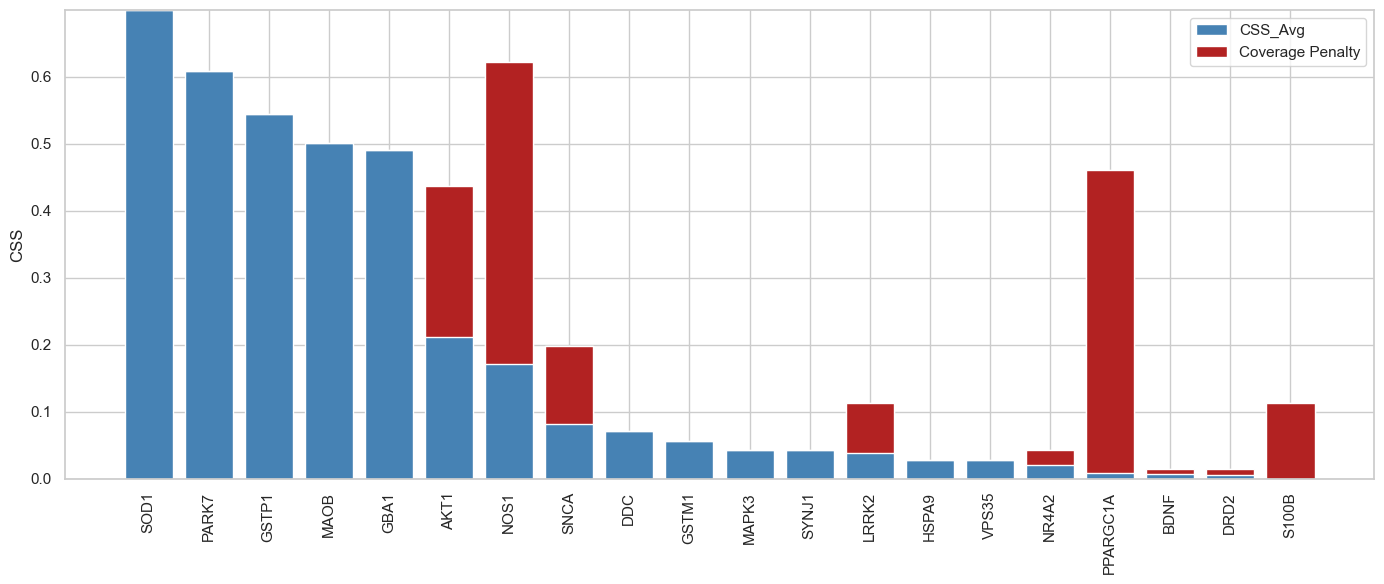

In [15]:
top_genes = df_sorted.head(20)
x = top_genes["Gene"]

plt.figure(figsize=(14, 6))
bar1 = plt.bar(x, top_genes["CSS_Avg"], label="CSS_Avg", color="steelblue")
bar2 = plt.bar(x, top_genes["CSS_Final"] - top_genes["CSS_Avg"], bottom=top_genes["CSS_Avg"],
               label="Coverage Penalty", color="firebrick")

plt.xticks(rotation=90)
plt.ylabel("CSS")
plt.legend()
plt.tight_layout()
plt.show()

### Combining GDA, Modulator Score, and Structural Coverage into a single Targetability Score (TS)

In the context of drug discovery and repositioning, gene prioritisation is essential for identifying the most promising therapeutic targets. Combining **Gene-Disease Association (GDA) scores**, **coverage of high-resolution crystal structures**, and **Modulator Scores (MS)** into a single, integrated **Targetability Score (TS)** helps quantify the **druggability** and **structural tractability** of a gene. This combined score incorporates multiple dimensions of a target’s **biological relevance** (GDA), **structural availability** (coverage of solved crystal structures), and **pharmacological evidence** (MS), thus providing a holistic assessment of a gene's suitability for drug development.

Given that these individual scores have different ranges and scales, they need to be **normalised and combined using a weighted model**. To capture the **relative importance** of each factor, a **multi-objective approach** can be used, where each score contributes based on its biological significance for the specific disease context. The general assumption is that a **higher GDA score** indicates greater disease relevance, a **higher coverage percentage** reflects better structural tractability, and a **higher MS** reflects the potential for therapeutic modulation via known small molecules.

The equation for combining these scores into a **Targetability Score (TS)** is formulated as:

$$
TS = \frac{w_1 \cdot \sigma_{k, m_1}(MS) + w_2 \cdot \sigma_{\frac{k}{10}, m_2}(Coverage) + w_3 \cdot \sigma_{k, m_3}(GDA)}{w_1 + w_2 + w_3}
$$

Where:

* **MS** is the **Modulator Score** (Global),
* **Coverage** is the **percentage of structurally resolved protein sequence**, based on X-ray structures ≤2.5 Å,
* **GDA** is the **Gene-Disease Association Score**,
* **\$w\_1, w\_2, w\_3\$** are the weights assigned to **MS**, **Coverage**, and **GDA** respectively,
* **\$\sigma\_{k, m}(x) = \frac{1}{1 + e^{-k(x - m)}}\$** is the sigmoid transformation applied to each input feature, where:

  * \$k\$ controls the steepness of the curve,
  * \$m\$ is the midpoint at which the sigmoid outputs 0.5.

For this analysis, the following parameter values were used:

* \$w\_1 = 0.6\$, \$w\_2 = 0.3\$, \$w\_3 = 0.1\$
* \$k = 15\$
* \$m\_1 = 0.015\$ for **Modulator Score**
* \$m\_2 = 90\$ for **Coverage Percent**
* \$m\_3 = 0.8\$ for **GDA Score**

This formulation allows the Targetability Score to integrate biologically meaningful features with **soft saturation** and **non-linear weighting**, enabling more nuanced prioritisation across a diverse set of genes.


In [16]:
def sigmoid(x, k=10, mid=0.05):
    return 1 / (1 + np.exp(-k * (x - mid)))

def compute_ts(row, w_mod=0.6, w_cov=0.3, w_gda=0.1, k=15, mid_mod=0.015, mid_cov=90, mid_gda=0.8):
    mod = row.get("ModulatorScore_Global", 0) or 0
    coverage = row.get("coverage_percent", 0) or 0
    gda = row.get("ScoreGDA", 0) or 0
    mod_s = sigmoid(mod, k=k, mid=mid_mod)
    cov_s = sigmoid(coverage, k=k/10, mid=mid_cov)
    gda_s = sigmoid(gda, k=k, mid=mid_gda)
    ts = (w_mod * mod_s + w_cov * cov_s + w_gda * gda_s) / (w_mod + w_cov + w_gda)
    return ts
    
df_sorted["TS"] = df_sorted.apply(compute_ts, axis=1)
df_sorted = df_sorted.sort_values("TS", ascending=False).reset_index(drop=True)
df_sorted.to_csv("../data/targetability_score.csv", index = False)

/var/folders/y0/rzqb79d51rl7nd2k33qy2tww0000gn/T/ipykernel_81607/1755175840.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ScoreType", y="Rank", data=ranked_df, palette="Set2", showmeans=True)


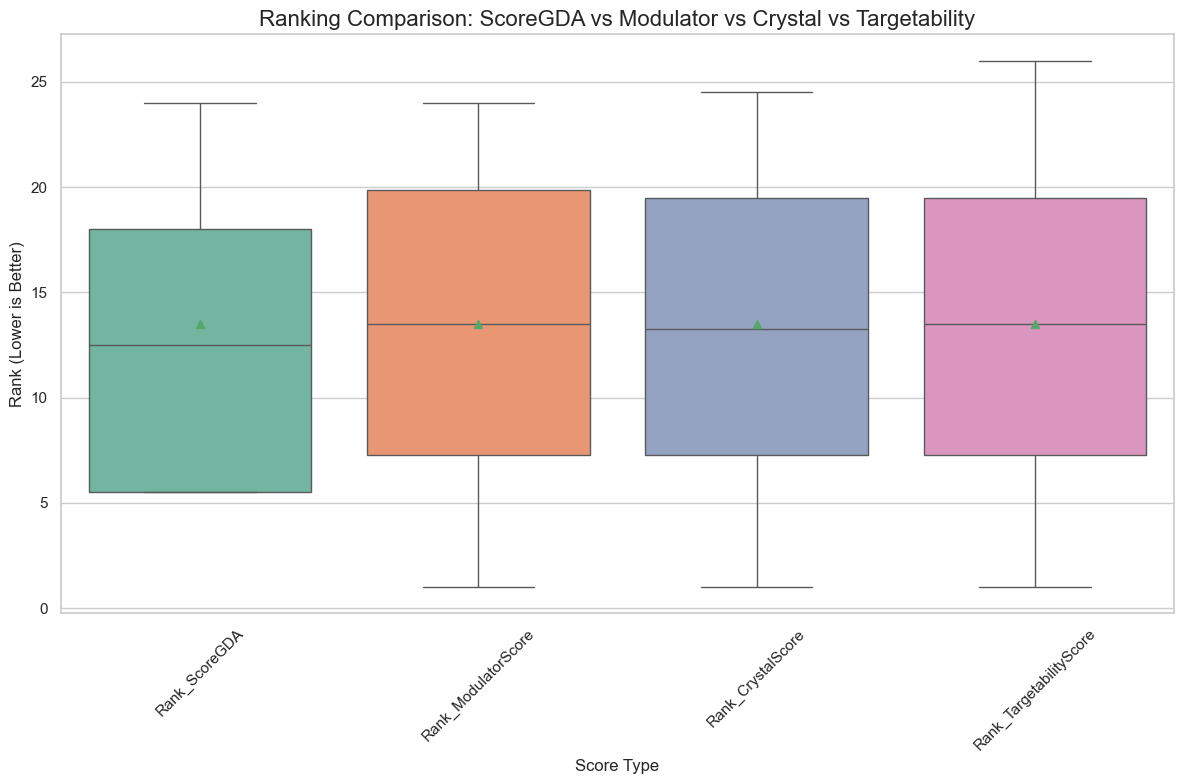

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create new columns for ranks of each score
df_sorted["Rank_ScoreGDA"] = df_sorted["ScoreGDA"].rank(ascending=False)
df_sorted["Rank_ModulatorScore"] = df_sorted["ModulatorScore_Global"].rank(ascending=False)
df_sorted["Rank_CrystalScore"] = df_sorted["CrystalScore_Global"].rank(ascending=False)
df_sorted["Rank_TargetabilityScore"] = df_sorted["TS"].rank(ascending=False)

# Melt the dataframe for easy plotting
ranked_df = df_sorted[["Gene", "Rank_ScoreGDA", "Rank_ModulatorScore", "Rank_CrystalScore", "Rank_TargetabilityScore"]]
ranked_df = ranked_df.melt(id_vars="Gene", var_name="ScoreType", value_name="Rank")

# Set up the plot
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Create the plot
sns.boxplot(x="ScoreType", y="Rank", data=ranked_df, palette="Set2", showmeans=True)

# Adjust plot
plt.title("Ranking Comparison: ScoreGDA vs Modulator vs Crystal vs Targetability", fontsize=16)
plt.xlabel("Score Type", fontsize=12)
plt.ylabel("Rank (Lower is Better)", fontsize=12)
plt.xticks(rotation=45)

# Display the plot
plt.tight_layout()
plt.show()

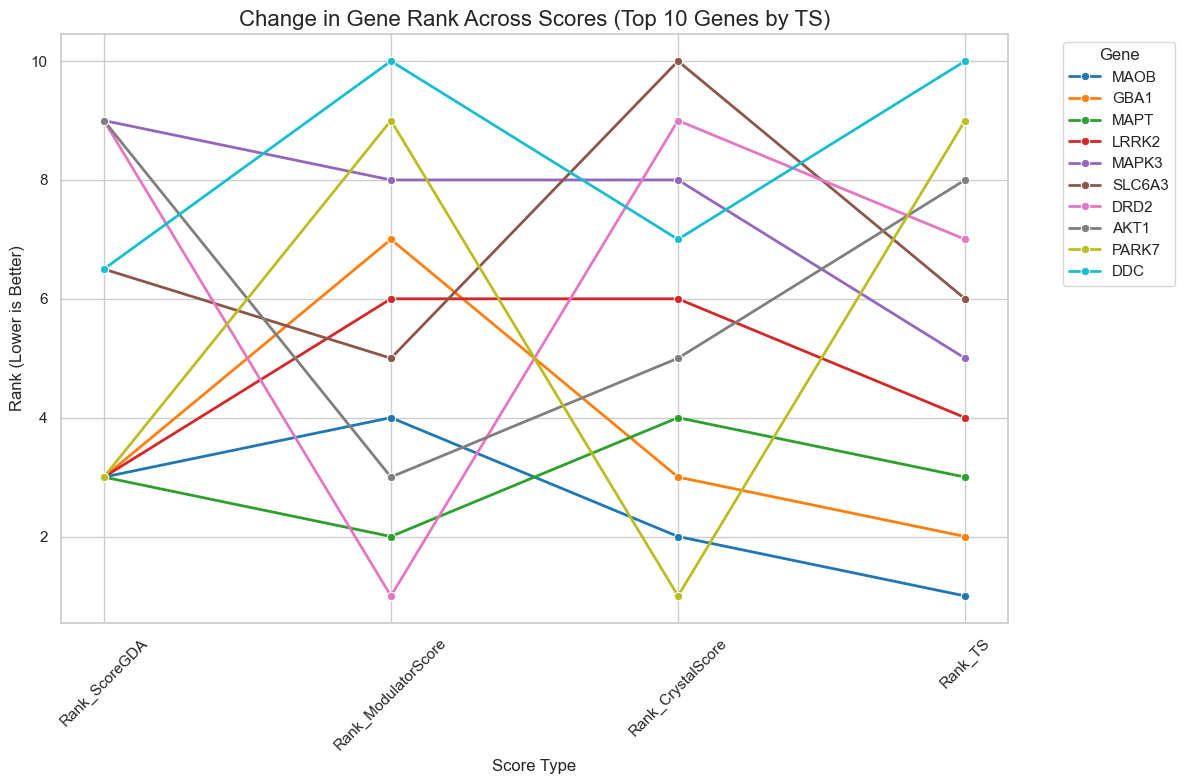

In [18]:
top_genes = df_sorted.sort_values(by="TS", ascending=False)["Gene"].head(10)

# Filter df_sorted to include only the top genes
ranked_genes_df = df_sorted[df_sorted["Gene"].isin(top_genes)].copy()

# Compute ranks for each scoring method
ranked_genes_df["Rank_ScoreGDA"] = ranked_genes_df["ScoreGDA"].rank(ascending=False)
ranked_genes_df["Rank_ModulatorScore"] = ranked_genes_df["ModulatorScore_Global"].rank(ascending=False)
ranked_genes_df["Rank_CrystalScore"] = ranked_genes_df["CrystalScore_Global"].rank(ascending=False)
ranked_genes_df["Rank_TS"] = ranked_genes_df["TS"].rank(ascending=False)

# Melt for plotting
ranked_genes_long_df = ranked_genes_df.melt(
    id_vars=["Gene"],
    value_vars=[
        "Rank_ScoreGDA",
        "Rank_ModulatorScore",
        "Rank_CrystalScore",
        "Rank_TS"
    ],
    var_name="ScoreType",
    value_name="Rank"
)

# Plotting
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

sns.lineplot(
    x="ScoreType",
    y="Rank",
    hue="Gene",
    data=ranked_genes_long_df,
    marker="o",
    lw=2,
    palette="tab10"
)

# Customize
plt.title("Change in Gene Rank Across Scores (Top 10 Genes by TS)", fontsize=16)
plt.xlabel("Score Type", fontsize=12)
plt.ylabel("Rank (Lower is Better)", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Gene", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


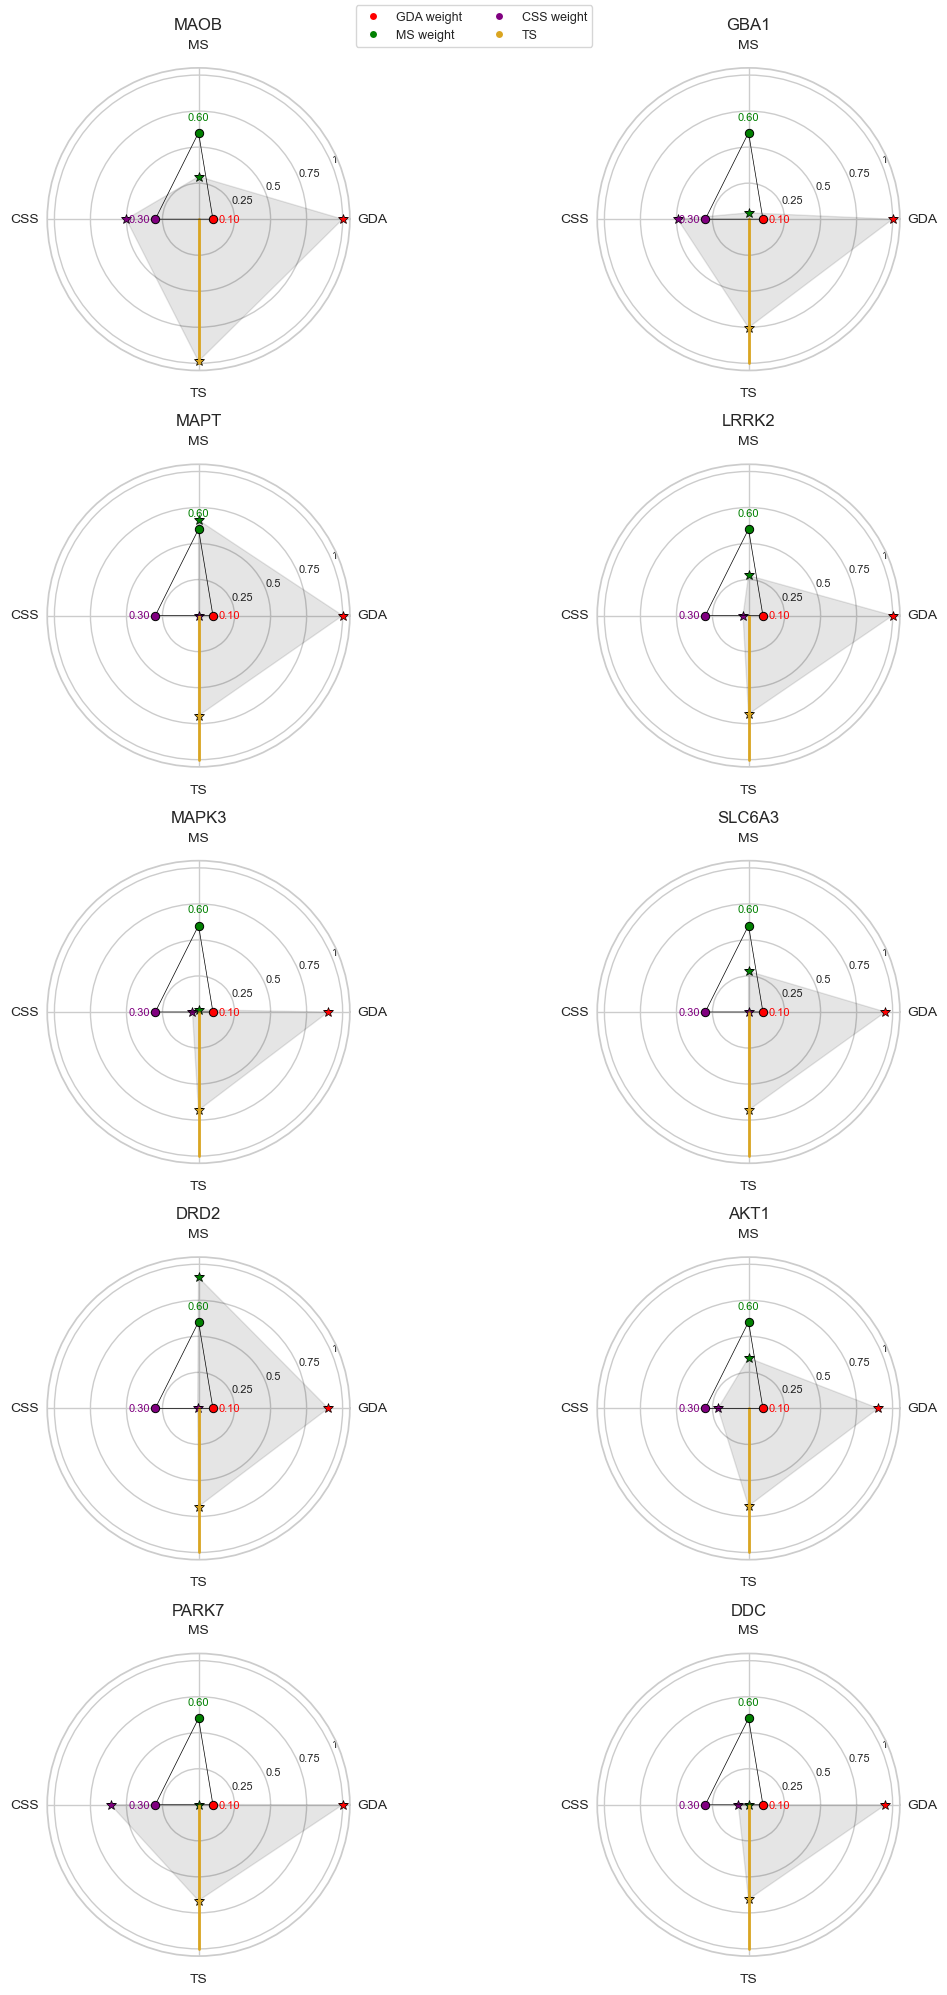

In [19]:
top_genes = df_sorted.sort_values("TS", ascending=False).head(10).copy()
top_genes["GDA"] = top_genes["ScoreGDA"]
top_genes["MS"] = top_genes["ModulatorScore_Global"]
top_genes["CSS"] = top_genes["CSS_Final"]
top_genes["TS"] = top_genes["TS"]

categories = ["GDA", "MS", "CSS", "TS"]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # close the loop

# Weight vector for triangle
weights_raw = [0.1, 0.6, 0.3]
norm = sum(weights_raw)
weights_normalized = [w / norm for w in weights_raw]
weights_values = weights_normalized + [weights_normalized[0]]
weight_angles = angles[:-1]  # exclude TS angle
weight_angles += [weight_angles[0]]  # close triangle

max_vals = {
    "GDA": df_sorted["ScoreGDA"].max(),
    "MS": df_sorted["ModulatorScore_Global"].max(),
    "CSS": df_sorted["CSS_Final"].max(),
    "TS": df_sorted["TS"].max()
}

fig, axs = plt.subplots(5, 2, figsize=(12, 20), subplot_kw=dict(polar=True))
axs = axs.flatten()

for i, (idx, row) in enumerate(top_genes.iterrows()):
    values = [row[c] for c in categories]
    values += values[:1]  # close radar
    ax = axs[i]
    vertex_colors = ['red', 'green', 'purple', 'goldenrod']  # GDA, MS, CSS, TS
    for angle, value, vcolor in zip(angles[:-1], values[:-1], vertex_colors):
        ax.plot(angle, value, marker='*', markersize=7, color=vcolor, markeredgecolor='black', markeredgewidth=0.5)
    ax.plot(angles, values, linewidth=0, linestyle='solid', color='black', alpha=0.5)
    ax.fill(angles, values, alpha=0.1, color='black')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(["GDA", "MS", "CSS", "TS"], fontsize=10)
    ax.set_yticks([0.25, 0.5, 0.75, 1])
    ax.set_yticklabels(['0.25', '0.5', '0.75', '1'], fontsize=8)
    ax.set_title(row["Gene"], size=12, y=1.1)
    ax.grid(True)
    highlight_angle = angles[3]
    ax.plot([highlight_angle, highlight_angle], [0, 1], color='goldenrod', linestyle='-', linewidth=2)
    # Create 3 angles for GDA, MS, CSS only
    triangle_angles = angles[:3] + [angles[0]] 
    triangle_r = [w * 1 for w in weights_normalized] + [weights_normalized[0] * 1]
    ax.plot(triangle_angles, triangle_r, color="black", linestyle="-", linewidth=0.5)
    triangle_labels = ['0.10', '0.60', '0.30']
    triangle_colors = ['red', 'green', 'purple']
    for ang, rad, label, color in zip(triangle_angles[:-1], triangle_r[:-1], triangle_labels, triangle_colors):
        label_r = rad + 0.11 * 1
        ax.text(
            ang,
            label_r,
            label,
            ha='center',
            va='center',
            fontsize=8,
            color=color,
            rotation=0
        )
        ax.plot(ang, rad, marker='o', markersize=6, color=color, markeredgecolor='black', markeredgewidth=0.7)

for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='GDA weight', markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='MS weight', markerfacecolor='green', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='CSS weight', markerfacecolor='purple', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='TS', markerfacecolor='goldenrod', markersize=6),
]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=9, frameon=True)

plt.tight_layout()
plt.show()

To better understand the relationship between raw feature profiles and our composite TS, we compared the **radar plot polygon area** (RadarArea) to the TS rank across the top 10 genes. The radar area represents the **unweighted geometric spread** across four features (GDA, MS, CSS, TS), treating all axes equally. In contrast, the TS is a **weighted aggregate**, assigning greater importance to MS (60%) and CSS (30%), and less to GDA (10%).

| Metric         | Interpretation                                                                                            |
| -------------- | --------------------------------------------------------------------------------------------------------- |
| **Radar Area** | Represents the **overall magnitude** across all features with **equal weighting**                         |
| **TS**         | Reflects a **weighted prioritization** of features, with emphasis on MS > CSS > GDA                       |
| **Divergence** | Radar area does **not account for feature weighting**, and therefore is **not expected to match TS rank** |

This analysis serves to quantify the **divergence between unweighted and weighted views** of gene prioritisation. A high radar area but low TS rank suggests a gene performs well in **lower-weighted dimensions** (e.g., GDA), whereas a high TS with modest area indicates **strong performance in more heavily weighted features** (e.g., MS).

This discrepancy is not a flaw but an expected outcome of the weighting scheme. The Spearman rank correlation coefficient (`ρ`) between RadarArea and TS ranks provides a useful summary of their alignment. A lower correlation reinforces the **importance of the weighting strategy** used in TS construction.

Importantly, this comparison offers a future direction for benchmarking. While our current machine learning (ML) training dataset is based on the **weighted TS-based gene prioritisation**, future work could compare ML performance against a dataset derived from **unweighted radar area rankings**. This would test whether the TS-driven enrichment contributes meaningfully to ML model performance, and help validate the biological relevance of the weighting scheme.

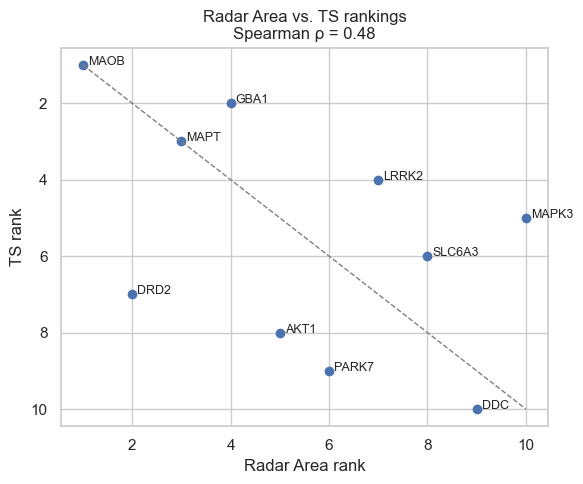

In [20]:
top_genes = df_sorted.sort_values("TS", ascending=False).head(10).copy()
top_genes["GDA"] = top_genes["ScoreGDA"]
top_genes["MS"] = top_genes["ModulatorScore_Global"]
top_genes["CSS"] = top_genes["CSS_Final"]
top_genes["TS"] = top_genes["TS"]

categories = ["GDA", "MS", "CSS", "TS"]
N = len(categories)
angles = np.array([n / float(N) * 2 * pi for n in range(N)])
angles = np.append(angles, angles[0])  # close the polygon

def polygon_area(values, angles):
    values = np.append(values, values[0])
    x = values * np.cos(angles)
    y = values * np.sin(angles)
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

top_genes["RadarArea"] = top_genes.apply(lambda row: polygon_area(row[categories].values, angles), axis=1)

top_genes["TS_Rank"] = top_genes["TS"].rank(ascending=False, method="first")
top_genes["RadarArea_Rank"] = top_genes["RadarArea"].rank(ascending=False, method="first")

corr, pval = spearmanr(top_genes["RadarArea_Rank"], top_genes["TS_Rank"])

plt.figure(figsize=(6, 5))
plt.scatter(top_genes["RadarArea_Rank"], top_genes["TS_Rank"])

for i, row in top_genes.iterrows():
    plt.text(row["RadarArea_Rank"] + 0.1, row["TS_Rank"], row["Gene"], fontsize=9)
plt.plot([1, 10], [1, 10], linestyle='--', color='gray', linewidth=1)

plt.xlabel("Radar Area rank")
plt.ylabel("TS rank")
plt.title(f"Radar Area vs. TS rankings\nSpearman ρ = {corr:.2f}")
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_targets = pd.read_csv("../data/targetability_score.csv")
df_chembl = pd.read_csv("../data/df_chembl.csv")

df_chembl.columns = df_chembl.columns.str.strip()
compound_cols = [
    "pChEMBL", "Assay ChEMBL ID", "Molecule ChEMBL ID", "Preferred name", "Molecule type",
    "Canonical SMILES", "Molecular weight of full compound", "Molecular formula of full compound",
    "Parent compound ChEMBL ID", "Active ingredient ChEMBL ID", "Target ChEMBL ID"
]
df_chembl_filtered = df_chembl[compound_cols]

df_merged = pd.merge(
    df_targets,
    df_chembl_filtered,
    how="inner",
    left_on="ChEMBLTargetID",
    right_on="Target ChEMBL ID"
)
df_merged = df_merged.sort_values(by=["Gene", "pChEMBL"], ascending=[True, False])
df_merged = df_merged.drop_duplicates(subset=["Molecule ChEMBL ID", "Target ChEMBL ID", "pChEMBL"])
allowed_types = ["Small molecule", "Protein", "Peptide (Inferred via PubChem)"]
df_merged = df_merged[df_merged["Molecule type"].isin(allowed_types)]
df_merged = df_merged[df_merged["Canonical SMILES"].notna()]
df_merged